# EDA: Detecção de Intrusão em Redes UAV

**Desafio:** Um sistema de drones de precisão agrícola opera em enxame (swarm) trocando dados de telemetria e comandos via rede FANET. Ataques de rede comprometem a integridade das operações, podendo derrubar drones, desviar rotas ou causar colisões. O objetivo é construir um classificador que, a partir de métricas de fluxo de rede, identifique em tempo real se um fluxo é tráfego normal ou um dos quatro ataques conhecidos: **Blackhole, Flooding, Sybil ou Wormhole**.

**Dataset:** UAVIDS-2025 
**URL:** https://dx.doi.org/10.21227/j5p4-zt27  

## Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import mutual_info_classif, f_classif

# Configuração visual padrão
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

RANDOM_STATE = 42
DATASET_PATH = 'UAVIDS-2025.csv'

# Paletas
PALETTE = {
    'Normal Traffic':   '#2196F3',   # azul
    'Blackhole Attack': '#F44336',   # vermelho
    'Flooding Attack':  '#FF9800',   # laranja
    'Sybil Attack':     '#9C27B0',   # roxo
    'Wormhole Attack':  '#E91E63',   # rosa
}

## 1. Carregamento e Inspeção Inicial

In [2]:
df = pd.read_csv(DATASET_PATH)

print(f'Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print()
df.info()

Dimensões: 122,171 linhas × 23 colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122171 entries, 0 to 122170
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   FlowID           122171 non-null  int64  
 1   FlowDuration/s   122171 non-null  float64
 2   SrcAddr          122171 non-null  object 
 3   SrcPort          122171 non-null  int64  
 4   DstAddr          122171 non-null  object 
 5   DstPort          122171 non-null  int64  
 6   Protocol         122171 non-null  object 
 7   TxPackets        122171 non-null  int64  
 8   RxPackets        122171 non-null  int64  
 9   LostPackets      122171 non-null  int64  
 10  TxBytes          122171 non-null  int64  
 11  RxBytes          122171 non-null  int64  
 12  TxPacketRate/s   122171 non-null  float64
 13  RxPacketRate/s   122171 non-null  float64
 14  TxByteRate/s     122171 non-null  float64
 15  RxByteRate/s     122171 non-null  float64
 16

**Função:** Gerar estatísticas descritivas de todas as colunas do dataset.

**Método:** `df.describe(include='all')` cobre variáveis numéricas (mean, std, percentis) e categóricas (unique, top). Usar `include='all'` garante que features com variância zero ou cardinalidade anômala sejam detectadas logo na primeira inspeção.

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
FlowID,122171.0,NaN,NaN,NaN,61086.0,35267.874206,1.0,30543.5,61086.0,91628.5,122171.0
FlowDuration/s,122171.0,NaN,NaN,NaN,696.714475,780.052068,0.000076,124.722,227.867,1415.655,10591.8
SrcAddr,122171,176,192.168.0.5,3341,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SrcPort,122171.0,NaN,NaN,NaN,169.137348,278.648982,9.0,9.0,9.0,9.0,654.0
DstAddr,122171,218,192.168.0.24,1929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DstPort,122171.0,NaN,NaN,NaN,169.137348,278.648982,9.0,9.0,9.0,9.0,654.0
Protocol,122171,1,UDP,122171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TxPackets,122171.0,NaN,NaN,NaN,486.930368,1933.094801,1.0,14.0,51.0,280.0,220886.0
RxPackets,122171.0,NaN,NaN,NaN,426.070737,1367.693106,0.0,5.0,23.0,196.0,63653.0
LostPackets,122171.0,NaN,NaN,NaN,60.436159,1149.330904,0.0,4.0,12.0,50.0,212557.0


**Função:** Inspecionar os valores brutos de uma amostra para confirmar que o carregamento do CSV foi correto.

**Método:** `df.head()` retorna as 5 primeiras linhas. É a verificação mais rápida de que tipos, separadores e encoding foram lidos como esperado, sem precisar abrir o arquivo.

In [4]:
df.head()

,FlowID,FlowDuration/s,SrcAddr,SrcPort,DstAddr,DstPort,Protocol,TxPackets,RxPackets,LostPackets,...,RxPacketRate/s,TxByteRate/s,RxByteRate/s,MeanDelay/s,MeanJitter/s,Throughput/Kbps,MeanPacketSize,PacketDropRate,AverageHopCount,label
0,1,175.007,192.168.0.150,9,192.168.0.16,9,UDP,251,215,36,...,1.22853,109.002,93.3679,0.022152,0.024406,0.746943,76,0.143426,0.074419,Sybil Attack
1,2,175.008,192.168.0.150,9,192.168.0.19,9,UDP,251,223,28,...,1.27423,109.001,96.8411,0.019637,0.018678,0.774729,76,0.111554,0.053812,Sybil Attack
2,3,175.010,192.168.0.150,9,192.168.0.24,9,UDP,251,224,27,...,1.27993,108.999,97.2744,0.023701,0.023917,0.778195,76,0.107570,0.044643,Sybil Attack
3,4,175.014,192.168.0.150,9,192.168.0.34,9,UDP,251,212,39,...,1.21133,108.997,92.0614,0.034014,0.025408,0.736491,76,0.155378,0.033019,Sybil Attack
4,5,175.017,192.168.0.150,9,192.168.0.39,9,UDP,251,215,36,...,1.22845,108.995,93.3623,0.034396,0.024933,0.746899,76,0.143426,0.009302,Sybil Attack


**Função:** Confirmar que cada coluna foi importada no tipo correto e identificar erros de parsing.

**Método:** `df.dtypes` lista o tipo inferido pelo pandas por coluna. Features numéricas devem ser `int64`/`float64`; se alguma aparecer como `object`, indica valores não numéricos misturados que exigiriam conversão antes do pipeline.

In [5]:
print(df.dtypes.to_string())

FlowID               int64
FlowDuration/s     float64
SrcAddr             object
SrcPort              int64
DstAddr             object
DstPort              int64
Protocol            object
TxPackets            int64
RxPackets            int64
LostPackets          int64
TxBytes              int64
RxBytes              int64
TxPacketRate/s     float64
RxPacketRate/s     float64
TxByteRate/s       float64
RxByteRate/s       float64
MeanDelay/s        float64
MeanJitter/s       float64
Throughput/Kbps    float64
MeanPacketSize       int64
PacketDropRate     float64
AverageHopCount    float64
label               object


**Observações da inspeção inicial:**
- `FlowID`: inteiro sequencial identificador puro, será **removido** antes da modelagem
- `SrcAddr`, `DstAddr`: strings de endereço IP parecem ter cardinalidade alta
- `Protocol`: string única feature categórica, verificar se tem variância (se for constante, melhor descartar)
- Features numéricas de volume têm escala varias vezes maior que features de performance, deve-se usar o StandardScaler obrigatório para padronização.
- Nenhum erro encontrado, isso porque o dataset foi gerado por simulação controlada

## 2. Distribuição da Variável-Alvo

In [6]:
contagem = df['label'].value_counts()
percentual = df['label'].value_counts(normalize=True).mul(100).round(1)

dist_target = pd.DataFrame({
    'Contagem': contagem,
    'Percentual (%)': percentual
})
print('Distribuição da variável-alvo:')
print(dist_target.to_string())

ratio = contagem.max() / contagem.min()
print(f'\nRazão máx/mín: {ratio:.2f}x')
print(f'Classe majoritária: {contagem.idxmax()} ({contagem.max():,})')
print(f'Classe minoritária: {contagem.idxmin()} ({contagem.min():,})')

Distribuição da variável-alvo:
                  Contagem  Percentual (%)
Normal Traffic       26172            21.4
Blackhole Attack     26110            21.4
Wormhole Attack      26086            21.4
Sybil Attack         24077            19.7
Flooding Attack      19726            16.1

Razão máx/mín: 1.33x
Classe majoritária: Normal Traffic (26,172)
Classe minoritária: Flooding Attack (19,726)


**Função:** Visualizar o desbalanceamento entre classes para decidir a estratégia de treinamento.

**Método:** `value_counts()` + gráfico de barras com anotação percentual. Barras são preferíveis a pie charts para comparar proporções próximas (ex.: Blackhole 21,4% vs. Normal 21,4%). O diagnóstico de desbalanceamento moderado justifica o uso de `class_weight='balanced'` em todos os modelos.

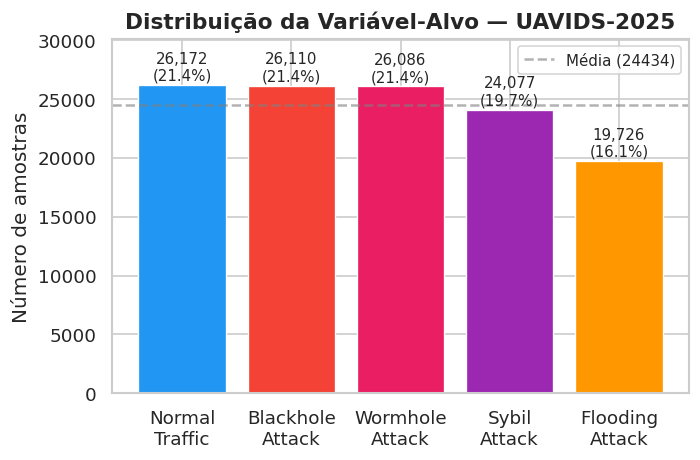

In [7]:
ordem = list(contagem.index)

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    [c.replace(' ', '\n') for c in ordem],
    [contagem[c] for c in ordem],
    color=[PALETTE[c] for c in ordem],
    edgecolor='white', linewidth=0.8
)
for bar, cls in zip(bars, ordem):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f'{contagem[cls]:,}\n({percentual[cls]}%)',
        ha='center', va='bottom', fontsize=9
    )
ax.set_title('Distribuição da Variável-Alvo — UAVIDS-2025', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de amostras')
ax.set_ylim(0, contagem.max() * 1.15)
ax.axhline(contagem.mean(), color='gray', linestyle='--', alpha=0.6, label=f'Média ({contagem.mean():.0f})')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Análise do gráfico (Distribuição da Variável-Alvo):**

- Normal Traffic: 26.172 (21,4%) - Blackhole: 26.110 (21,4%) - Wormhole: 26.086 (21,4%) - Sybil: 24.077 (19,7%) - Flooding: 19.726 (16,1%)
- Três classes praticamente empatadas em 21,4%, Flooding cerca de 5 pontos percentuais abaixo.
- Razão máx/mín ~ 1,33x: desbalanceamento moderado, não exige SMOTE nem undersampling.
- Decisão: usar `class_weight='balanced'` para evitar que a Flooding fique sub-representada no treinamento.

## 3. Distribuições das Features Numéricas

In [8]:
# Definindo grupos de features por categoria (conforme Tabela III do artigo)
CONNECTION_FEATURES = ['FlowDuration/s', 'SrcPort', 'DstPort']
VOLUME_FEATURES = [
    'TxPackets', 'RxPackets', 'LostPackets',
    'TxBytes', 'RxBytes',
    'TxPacketRate/s', 'RxPacketRate/s',
    'TxByteRate/s', 'RxByteRate/s',
    'MeanPacketSize'
]
PERFORMANCE_FEATURES = [
    'MeanDelay/s', 'MeanJitter/s',
    'Throughput/Kbps', 'PacketDropRate', 'AverageHopCount'
]

NUM_FEATURES = CONNECTION_FEATURES + VOLUME_FEATURES + PERFORMANCE_FEATURES
CAT_FEATURES = ['Protocol']  # SrcAddr e DstAddr analisados separadamente

print(f'Features numéricas: {len(NUM_FEATURES)}')
print(f'Features categóricas (úteis): {len(CAT_FEATURES)}')
print(f'Identificadores a remover: FlowID, SrcAddr, DstAddr')

Features numéricas: 18
Features categóricas (úteis): 1
Identificadores a remover: FlowID, SrcAddr, DstAddr


**Função:** Analisar a distribuição das features de conexão e identificar caudas longas ou bimodalidade.

**Método:** `sns.histplot(kde=True)` o KDE sobreposto permite ver a forma contínua da distribuição. Features com cauda longa (como FlowDuration) exigem log-transform ou StandardScaler robusto antes da modelagem.

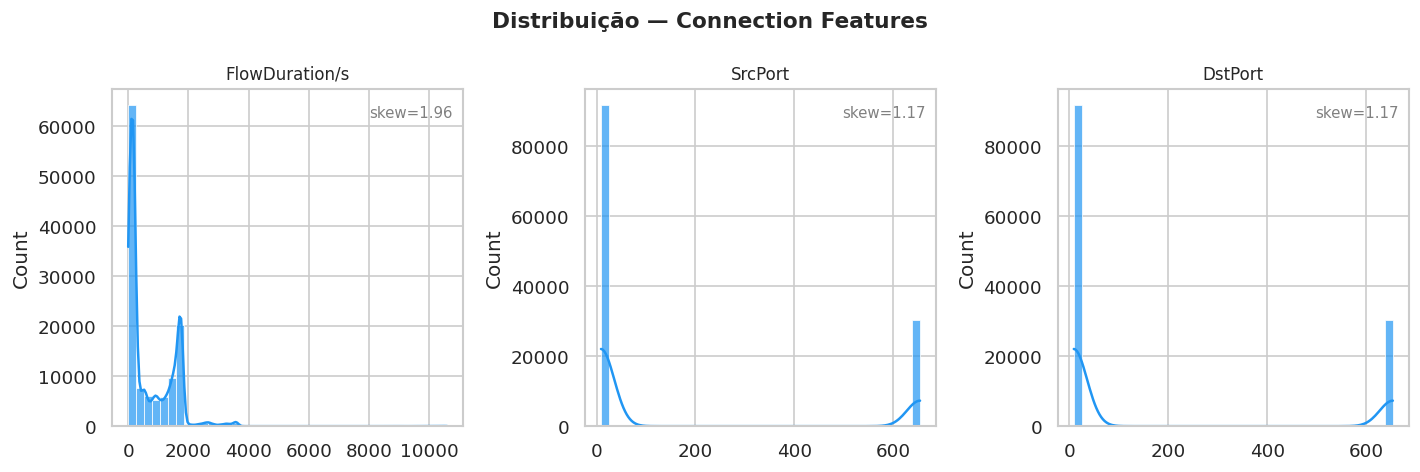

In [9]:
# Histogramas — Connection Features
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Distribuição — Connection Features', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, CONNECTION_FEATURES):
    sns.histplot(df[feat], bins=40, kde=True, ax=ax, color='#2196F3', alpha=0.7)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')
    skew = df[feat].skew()
    ax.text(0.97, 0.95, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

**Análise do gráfico (Connection Features):**

- **FlowDuration/s (skew=1,96):** cauda direita forte. Pico principal em fluxos curtos (até cerca de 200s, mais de 60 mil amostras) e segundo pico secundário próximo a 1.800-2.000s, sugerindo dois regimes de tráfego (sessões curtas e sessões prolongadas).
- **SrcPort e DstPort (skew=1,17):** distribuição bimodal idêntica entre as duas portas, dois clusters dominantes (faixa baixa próxima de 0-50 com cerca de 90 mil amostras e faixa alta próxima de 650 com cerca de 30 mil). Padrão típico de portas efêmeras vs. portas de serviço.
- Implicação: as três precisam de `StandardScaler` para conviver com features de baixa magnitude. As portas têm pouca variabilidade interna e baixa correlação esperada com a classe.

**Função:** Inspecionar escala e assimetria das features de volume de tráfego.

**Método:** `sns.histplot(kde=True)` em grid 2x5. Features de contagem (TxPackets, RxBytes) tendem a distribuições fortemente assimétricas identificar isso aqui justifica o uso de `StandardScaler` no pipeline em vez de `MinMaxScaler`, que é mais sensível a outliers extremos.

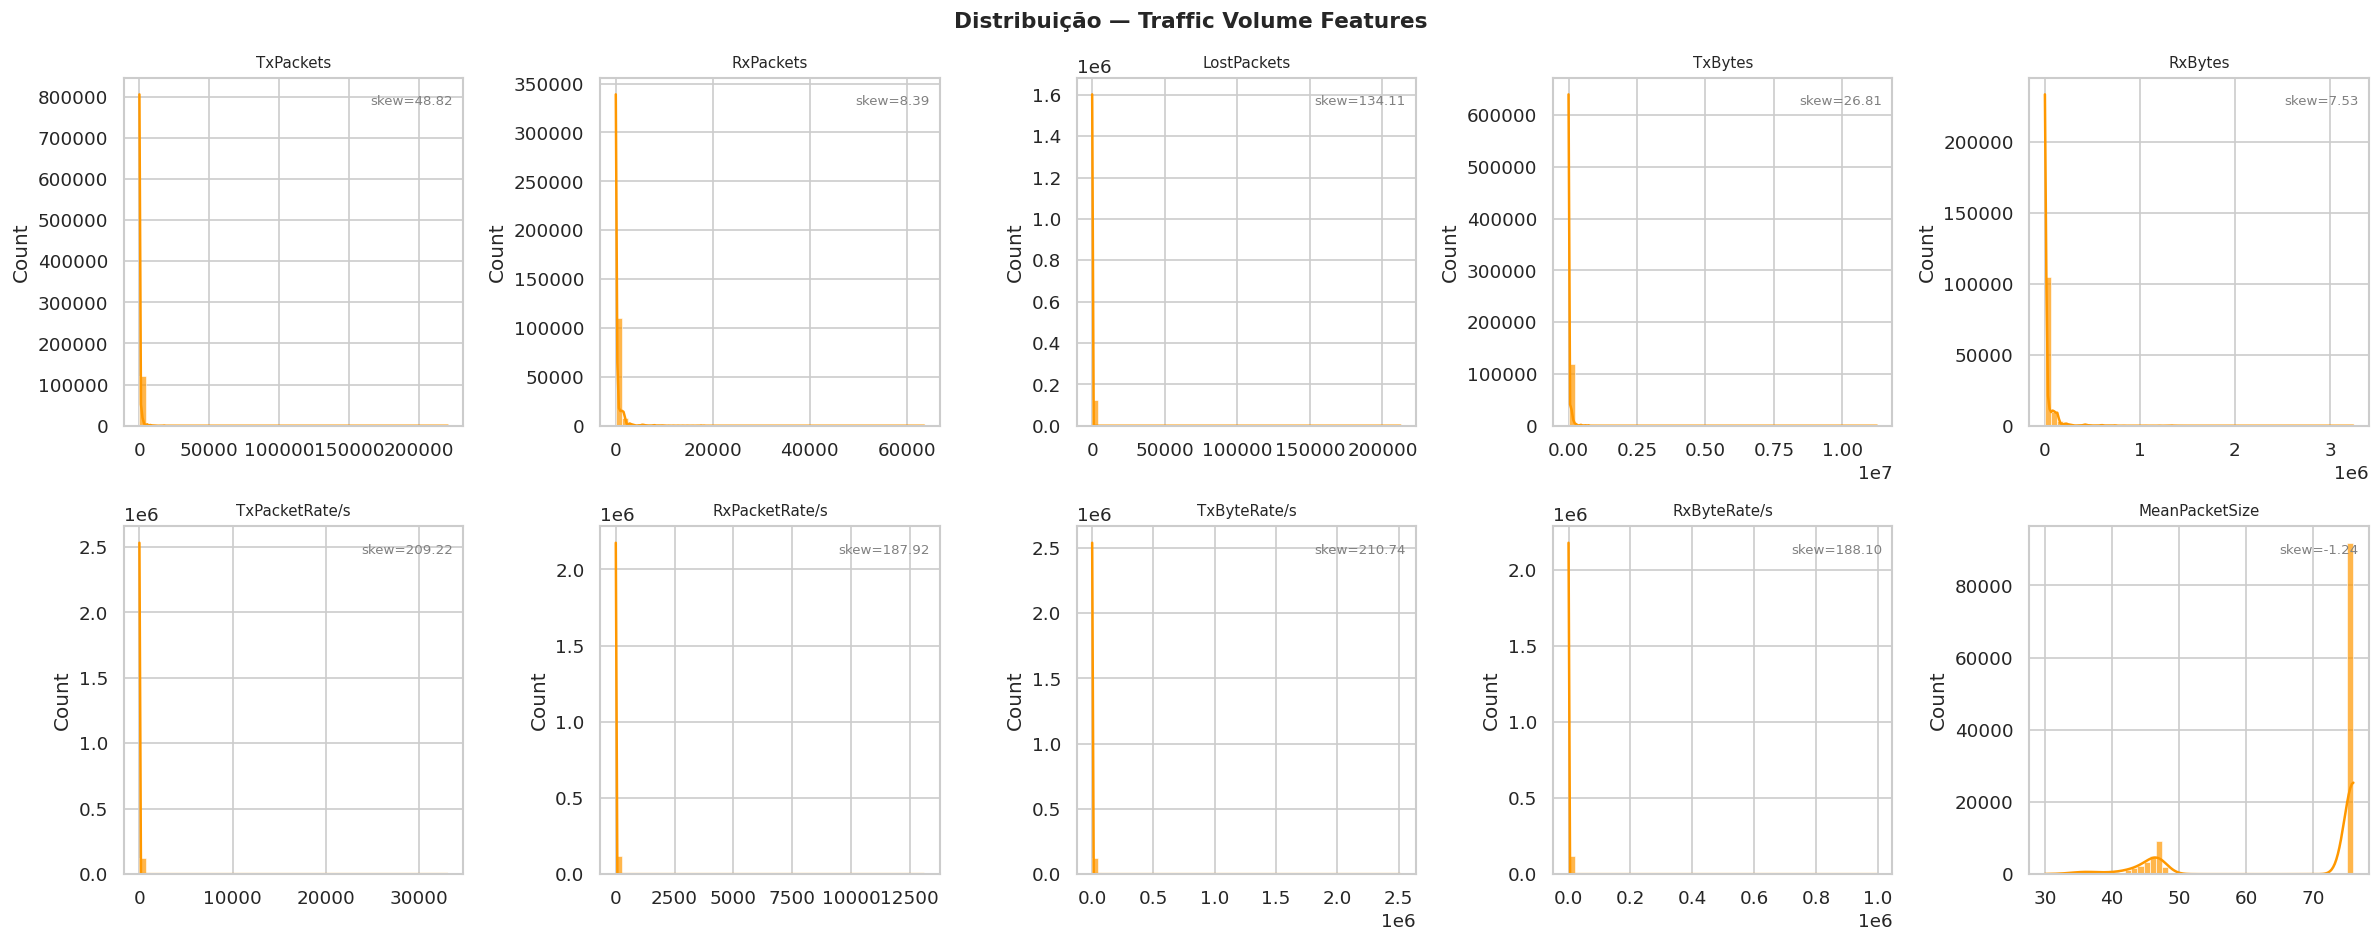

In [10]:
# Histogramas — Traffic Volume Features
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Distribuição — Traffic Volume Features', fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, feat in zip(axes, VOLUME_FEATURES):
    sns.histplot(df[feat], bins=50, kde=True, ax=ax, color='#FF9800', alpha=0.7)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
    skew = df[feat].skew()
    ax.text(0.97, 0.95, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

**Análise do gráfico (Traffic Volume Features):**

- Todas as 10 features de volume têm skew muito alto (TxPackets~88, RxPackets~8, LostPackets~130, TxBytes~26, RxBytes~7, TxPacketRate/s>200, RxPacketRate/s~187, TxByteRate/s~210, RxByteRate/s~180, MeanPacketSize~1,2).
- Visualmente, a distribuição concentra-se em uma única barra dominante próxima de zero com cauda extremamente longa, padrão típico de tráfego de rede onde poucos fluxos transportam grandes volumes.
- MeanPacketSize é a única feature aproximadamente normal (skew~1,2) com dois modos visíveis perto de 30 e 50 bytes.
- Implicação: features com cauda longa serão padronizadas com `StandardScaler` (modelos baseados em árvore lidam bem), mas qualquer modelo linear vai ser sensível ao impacto dos outliers.

**Função:** Identificar comportamentos extremos nas métricas de desempenho que são assinatura de ataques.

**Método:** `sns.histplot(kde=True)` MeanDelay, MeanJitter e PacketDropRate elevados são indicadores diretos de Flooding e Blackhole. Visualizar suas distribuições confirma o alto poder discriminativo esperado.

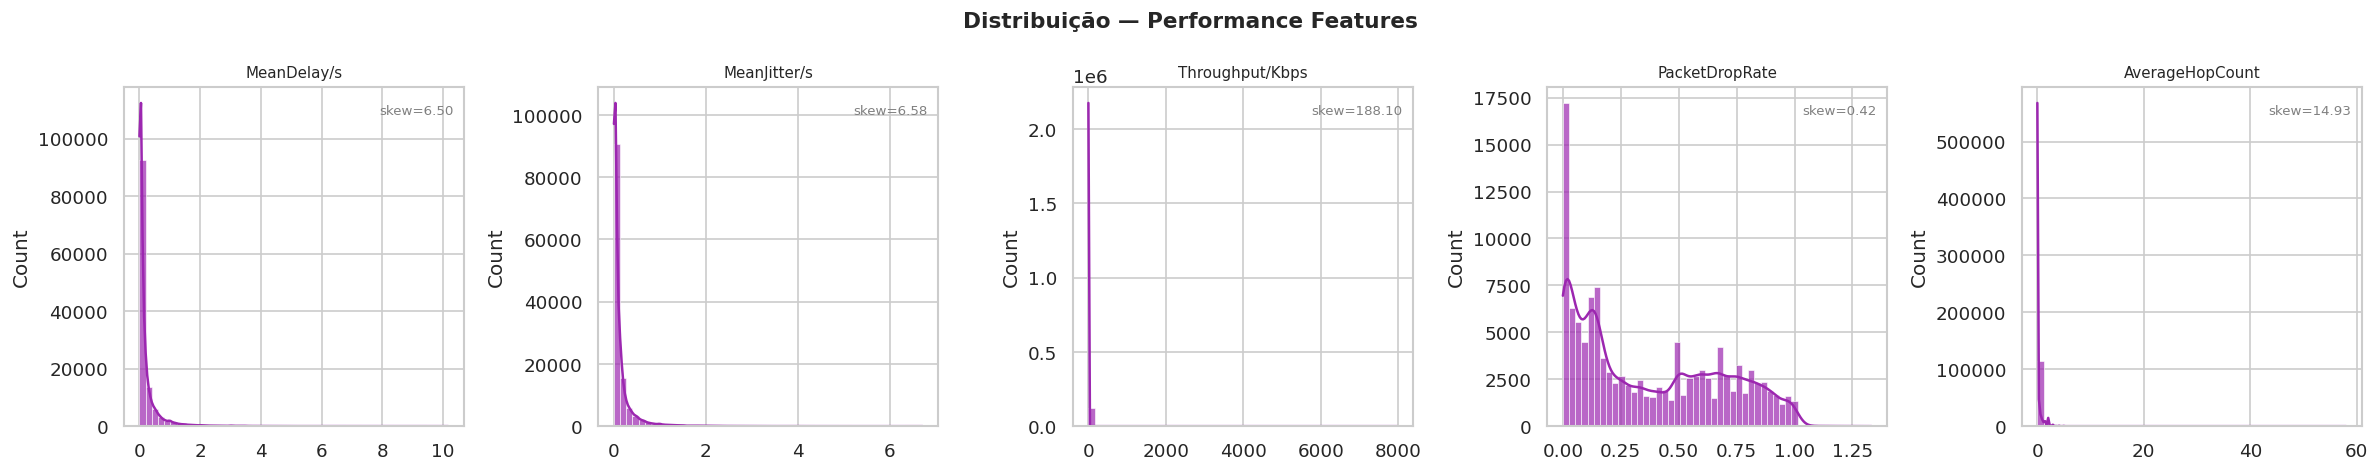

In [11]:
# Histogramas — Performance Features
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Distribuição — Performance Features', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, PERFORMANCE_FEATURES):
    sns.histplot(df[feat], bins=50, kde=True, ax=ax, color='#9C27B0', alpha=0.7)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
    skew = df[feat].skew()
    ax.text(0.97, 0.95, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

**Análise do gráfico (Performance Features):**

- **MeanDelay/s (skew=6,5) e MeanJitter/s (skew=6,58):** caudas longas, mas com massa concentrada perto de zero. Valores extremos (acima de 4s) são raros e provavelmente associados a ataques.
- **Throughput/Kbps (skew=188):** quase toda massa em zero (mais de 2 milhões de amostras no bin 0) com cauda gigante, indicando que poucos fluxos atingem alto throughput (provável assinatura do Flooding).
- **PacketDropRate (skew=0,42):** única feature aproximadamente uniforme entre 0 e 1, com pico no zero. Distribuição diferente das demais - é o sinal mais "limpo" do dataset.
- **AverageHopCount (skew=14,9):** mais de 500 mil amostras com HopCount próximo de zero, cauda chegando a 50. Diferencial topológico raro mas forte.

**Observações consolidadas das distribuições numéricas:**
- 14 das 15 features numéricas têm skew alto. Padronização (`StandardScaler`) é obrigatória dentro do Pipeline.
- PacketDropRate exige verificação adicional: existem 81 registros com valor > 1, que serão tratados via clip [0, 1] no `FunctionTransformer`.
- Throughput/Kbps, PacketDropRate e AverageHopCount são candidatos a discriminar Flooding, Blackhole e Wormhole respectivamente.

## 4. Distribuições das Features Categóricas

In [12]:
for col in ['Protocol', 'SrcAddr', 'DstAddr']:
    n_unique = df[col].nunique()
    print(f'{col}: {n_unique:,} valores únicos')

print()
print('Protocol — value_counts:')
vc = df['Protocol'].value_counts()
vc_pct = df['Protocol'].value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({'Contagem': vc, '%': vc_pct}).to_string())

Protocol: 1 valores únicos
SrcAddr: 176 valores únicos
DstAddr: 218 valores únicos

Protocol — value_counts:
     Contagem      %
UDP    122171  100.0


**Funcao:** Visualizar a distribuicao das features categoricas via countplot, conforme exigido pelo checklist.

**Metodo:** `sns.countplot` para Protocol (cardinalidade=1) e `sns.barplot` com `head(15)` do `value_counts` para SrcAddr e DstAddr (cardinalidade alta, > 100 valores unicos cada).

**Biblioteca:** seaborn.

In [ ]:
# Countplot das features categoricas
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Distribuicao das Features Categoricas', fontsize=14, fontweight='bold')

# Protocol: cardinalidade=1, countplot direto
sns.countplot(data=df, x='Protocol', ax=axes[0], color='#5C6BC0')
axes[0].set_title(f'Protocol (cardinalidade={df["Protocol"].nunique()})')
axes[0].set_ylabel('Contagem')
for p in axes[0].patches:
    h = p.get_height()
    axes[0].annotate(f'{int(h):,}\n({h/len(df)*100:.1f}%)',
                     (p.get_x() + p.get_width()/2., h),
                     ha='center', va='bottom', fontsize=10)

# SrcAddr: cardinalidade alta, top 15
top_src = df['SrcAddr'].value_counts().head(15)
sns.barplot(x=top_src.values, y=top_src.index, ax=axes[1], color='#26A69A', orient='h')
axes[1].set_title(f'Top 15 SrcAddr (cardinalidade={df["SrcAddr"].nunique()})')
axes[1].set_xlabel('Contagem')

# DstAddr: cardinalidade alta, top 15
top_dst = df['DstAddr'].value_counts().head(15)
sns.barplot(x=top_dst.values, y=top_dst.index, ax=axes[2], color='#FF7043', orient='h')
axes[2].set_title(f'Top 15 DstAddr (cardinalidade={df["DstAddr"].nunique()})')
axes[2].set_xlabel('Contagem')

plt.tight_layout()
plt.savefig('img/eda_img/eda_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nProtocol: {df["Protocol"].nunique()} valor unico -> feature constante')
print(f'SrcAddr:  {df["SrcAddr"].nunique()} IPs unicos -> cardinalidade alta')
print(f'DstAddr:  {df["DstAddr"].nunique()} IPs unicos -> cardinalidade alta')

**Analise do grafico (Features Categoricas):**

- **Protocol:** uma unica barra em UDP com 122.171 (100,0%). Cardinalidade = 1, variancia zero. Feature constante, sera removida.
- **SrcAddr:** 176 IPs unicos. As barras do top 15 sao aproximadamente uniformes (cada IP origem cerca de 700-800 amostras), sem uma categoria dominante. Cardinalidade alta para uma feature categorica.
- **DstAddr:** 218 IPs unicos. Distribuicao tambem aproximadamente uniforme no top 15. Mesma situacao do SrcAddr.
- Categorias raras: nenhum IP isolado domina, mas com 176 e 218 categorias cada, um OneHotEncoder geraria centenas de colunas binarias praticamente sem sinal preditivo.
- Decisao final: as 3 features categoricas serao descartadas (Protocol por ser constante, SrcAddr e DstAddr por serem identificadores de simulacao NS-3 que nao generalizam para producao).

**Decisões sobre features categóricas:**
- `Protocol`: **descartada**. É 100% UDP em todos os 122.171 registros variância zero, nenhum valor discriminativo. OneHotEncoding geraria uma coluna constante
- `SrcAddr` e `DstAddr`: **descartadas**. Apesar de cardinalidade moderada (176 e 218 IPs), são endereços de uma rede simulada fechada um modelo que aprende IPs específicos da simulação NS-3 não generaliza para redes reais. Em produção, os IPs mudam a cada missão de drone
- `FlowID`: **descartado**. Identificador sequencial sem valor preditivo
- **Lista final de features para modelagem:** todas as 18 numéricas exceto FlowID (Protocol e endereços IP removidos)

## 5. Relações Features x Alvo: Foco no Par Blackhole/Wormhole

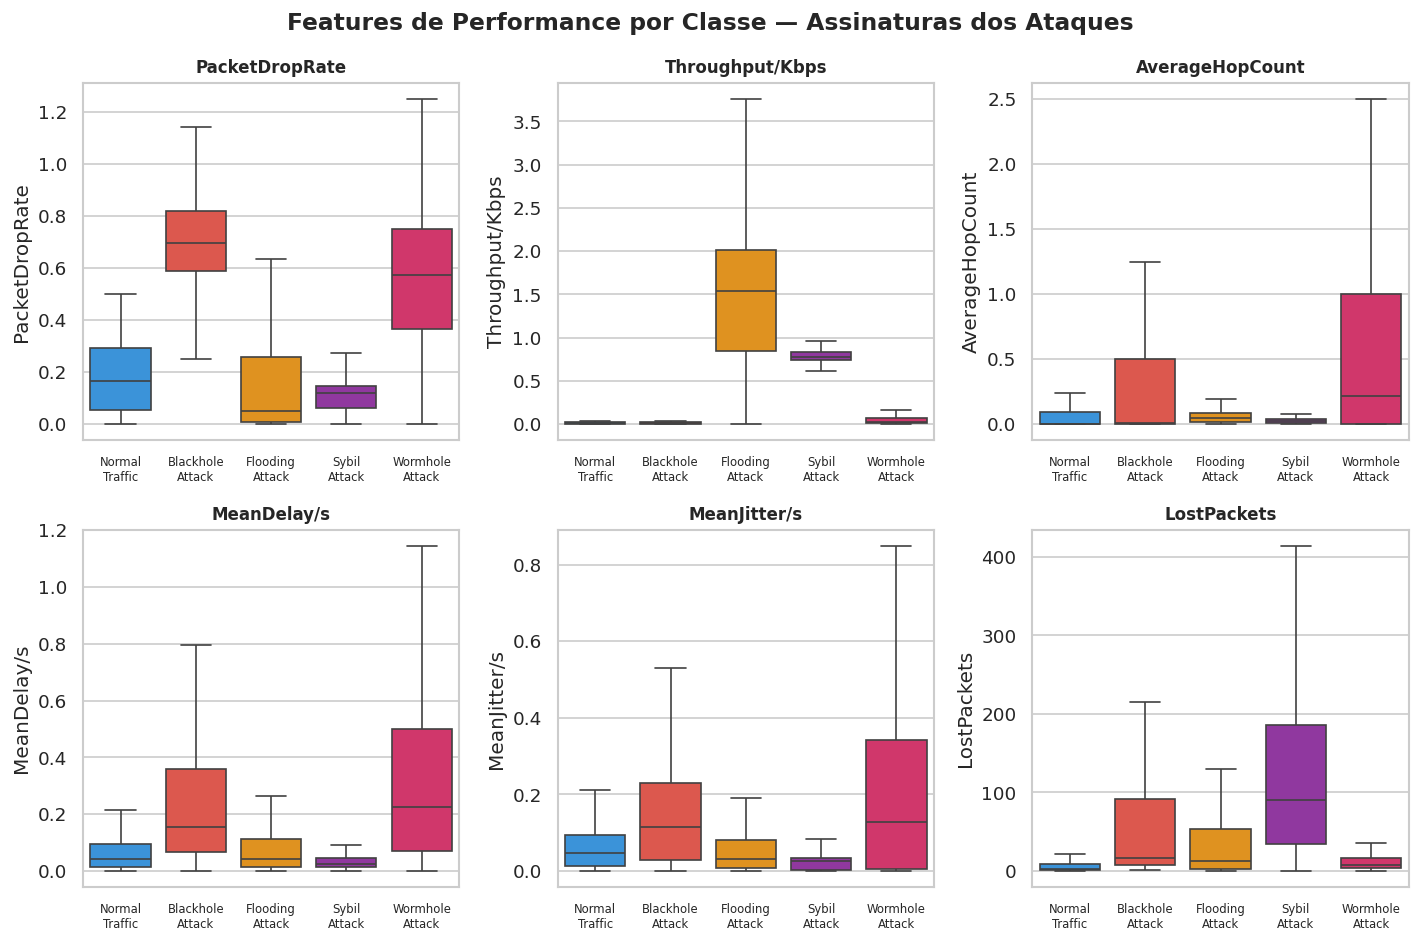

In [13]:
# Boxplots das features mais discriminativas por classe — todas as 5 classes
features_key = ['PacketDropRate', 'Throughput/Kbps', 'AverageHopCount',
                'MeanDelay/s', 'MeanJitter/s', 'LostPackets']

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Features de Performance por Classe — Assinaturas dos Ataques', 
             fontsize=14, fontweight='bold')
axes = axes.flatten()

ordem_classes = list(PALETTE.keys())

for ax, feat in zip(axes, features_key):
    sns.boxplot(
        data=df, x='label', y=feat,
        order=ordem_classes,
        palette=PALETTE,
        ax=ax,
        showfliers=False  # omitir outliers extremos para legibilidade
    )
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels([c.replace(' ', '\n') for c in ordem_classes], fontsize=7)

plt.tight_layout()
plt.show()

**Análise do gráfico (Boxplots de Performance por Classe):**

- **PacketDropRate:** Blackhole tem a mediana mais alta (~0,70, IQR 0,59-0,82), Wormhole vem em segundo (~0,58, IQR 0,37-0,76). Normal/Flooding/Sybil ficam abaixo de 0,20. Assinatura clara do Blackhole, que descarta pacotes ativamente.
- **Throughput/Kbps:** Flooding domina com mediana ~1,55 (IQR 0,84-2,00), Sybil em ~0,80, e as outras três classes praticamente em zero. Confirma o Flooding como gerador massivo de tráfego.
- **AverageHopCount:** Wormhole tem distribuição muito mais larga (IQR 0,01-1,01, máx ~2,5), Blackhole vai até ~1,25. Demais classes próximas de zero. Wormhole altera a topologia da rota, como esperado.
- **MeanDelay/s e MeanJitter/s:** Wormhole tem as maiores medianas (delay ~0,22, jitter ~0,14) seguido de Blackhole (delay ~0,15, jitter ~0,12). Confirmam que os túneis criados pelo Wormhole introduzem atraso e instabilidade.
- **LostPackets:** Sybil tem a mediana mais alta em valor absoluto (~90), Blackhole (~25), Flooding (~20). Diferente de PacketDropRate, esta é a contagem bruta, e revela o Sybil como o ataque que mais perde pacotes em volume.

**Função:** Verificar separabilidade bivariada usando duas features de desempenho de rede.

**Método:** Scatterplot com `hue` por classe em amostra de 15k pontos. O par MeanDelay x MeanJitter foi escolhido por representar duas dimensões ortogonais de degradação ataques que aumentam latência não necessariamente aumentam jitter na mesma proporção, criando clusters visualmente distintos.

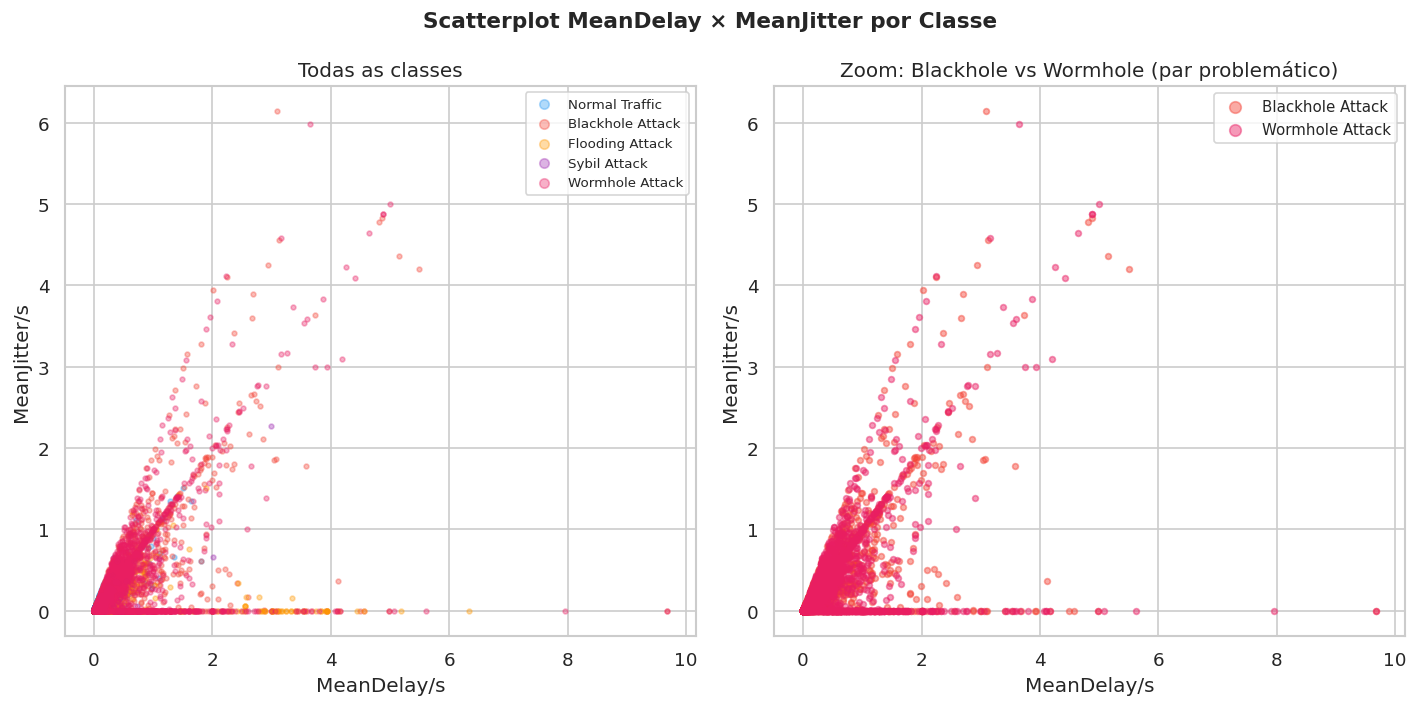

In [14]:
# Scatterplot MeanDelay × MeanJitter — par mais relevante para BH vs WH
# Subamostrar para visualização (100k pontos sobrepostos ficam ilegíveis)
df_sample = df.sample(n=min(15000, len(df)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Scatterplot MeanDelay × MeanJitter por Classe', 
             fontsize=13, fontweight='bold')

# Painel esquerdo: todas as classes
for cls in ordem_classes:
    subset = df_sample[df_sample['label'] == cls]
    axes[0].scatter(
        subset['MeanDelay/s'], subset['MeanJitter/s'],
        c=PALETTE[cls], label=cls, alpha=0.35, s=8
    )
axes[0].set_xlabel('MeanDelay/s')
axes[0].set_ylabel('MeanJitter/s')
axes[0].set_title('Todas as classes')
axes[0].legend(fontsize=8, markerscale=2)

# Painel direito: apenas BH vs WH — o par problemático
bh_wh = df_sample[df_sample['label'].isin(['Blackhole Attack', 'Wormhole Attack'])]
for cls in ['Blackhole Attack', 'Wormhole Attack']:
    subset = bh_wh[bh_wh['label'] == cls]
    axes[1].scatter(
        subset['MeanDelay/s'], subset['MeanJitter/s'],
        c=PALETTE[cls], label=cls, alpha=0.45, s=12
    )
axes[1].set_xlabel('MeanDelay/s')
axes[1].set_ylabel('MeanJitter/s')
axes[1].set_title('Zoom: Blackhole vs Wormhole (par problemático)')
axes[1].legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.show()

**Análise do gráfico (MeanDelay x MeanJitter por Classe):**

- **Painel esquerdo (todas as 5 classes):** Normal e Flooding aglomeradas no canto inferior esquerdo (delay e jitter próximos de zero). Sybil também concentrada nessa região. Blackhole e Wormhole se espalham para cima/direita em padrão diagonal, alcançando delay até cerca de 10s e jitter até 6s.
- **Painel direito (zoom Blackhole vs Wormhole):** as duas classes formam duas trilhas diagonais quase paralelas, com forte sobreposição. O Wormhole alcança valores extremos mais altos (cauda direita maior), mas não há fronteira clara separável neste par de features.
- Conclusão: delay e jitter discriminam ataques "lentos" (BH+WH) do tráfego comum, mas não separam Blackhole de Wormhole. Precisamos de outras features para esse par.

**Função:** Analisar a principal assinatura que distingue Blackhole do Wormhole o par mais difícil de separar.

**Método:** Scatterplot filtrado apenas para BH e WH (10k amostras). Blackhole descarta pacotes ativamente (PacketDropRate alto) enquanto Wormhole cria um túnel artificial aumentando HopCount. Esse par específico é a fronteira de decisão mais desafiadora do dataset, conforme apontado no artigo original.

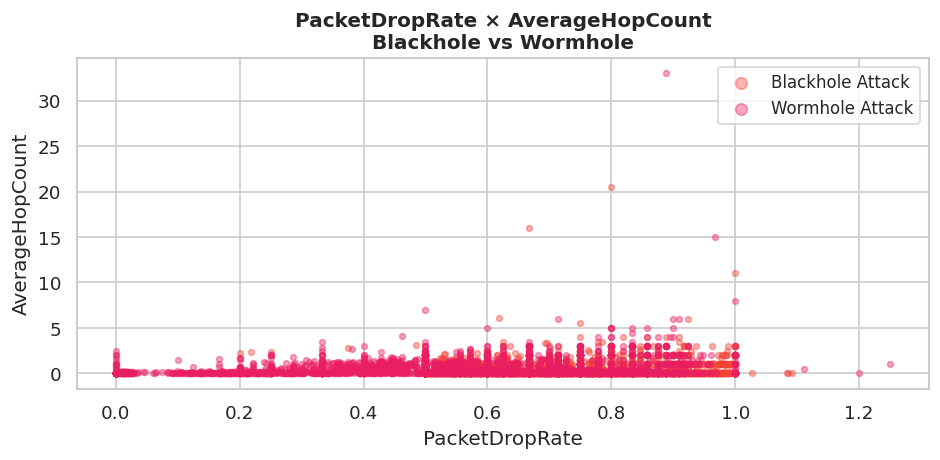

In [15]:
# PacketDropRate × AverageHopCount — assinatura primária BH vs WH segundo o artigo
fig, ax = plt.subplots(figsize=(8, 4))

bh_wh_full = df[df['label'].isin(['Blackhole Attack', 'Wormhole Attack'])].sample(
    n=min(10000, len(bh_wh)), random_state=RANDOM_STATE
)

for cls in ['Blackhole Attack', 'Wormhole Attack']:
    subset = bh_wh_full[bh_wh_full['label'] == cls]
    ax.scatter(
        subset['PacketDropRate'], subset['AverageHopCount'],
        c=PALETTE[cls], label=cls, alpha=0.4, s=12
    )

ax.set_xlabel('PacketDropRate')
ax.set_ylabel('AverageHopCount')
ax.set_title('PacketDropRate × AverageHopCount\nBlackhole vs Wormhole', fontweight='bold')
ax.legend(fontsize=10, markerscale=2)
plt.tight_layout()
plt.show()

**Análise do gráfico (PacketDropRate x AverageHopCount - Blackhole vs Wormhole):**

- A massa dos pontos de ambas as classes está concentrada na faixa AverageHopCount entre 0 e 2, espalhando-se por todo o eixo PacketDropRate (0 a 1).
- Outliers de Blackhole (laranja) atingem HopCount alto (7, 16, 20,5) e um outlier Wormhole (rosa) chega a HopCount=33.
- A sobreposição é massiva: a assinatura "primária" descrita pelo artigo (drop alto + hop alto = wormhole) só aparece em alguns outliers - a maioria dos pontos das duas classes ocupa a mesma região.
- Conclusão: este par de features sozinho não resolve BH<->WH. Justifica feature engineering (`loss_ratio`, `tx_efficiency`) para gerar separabilidade adicional.

**Observações consolidadas das relações features x alvo:**
- PacketDropRate isola Blackhole vs resto, Throughput isola Flooding, AverageHopCount captura Wormhole - mas nenhuma feature sozinha resolve o par BH<->WH.
- Próxima etapa: criar `loss_ratio = LostPackets / TxPackets` e `tx_efficiency = RxBytes / TxBytes` para amplificar a diferença entre quem descarta (BH) e quem reencaminha por túneis (WH).

## 6. Matriz de Correlação

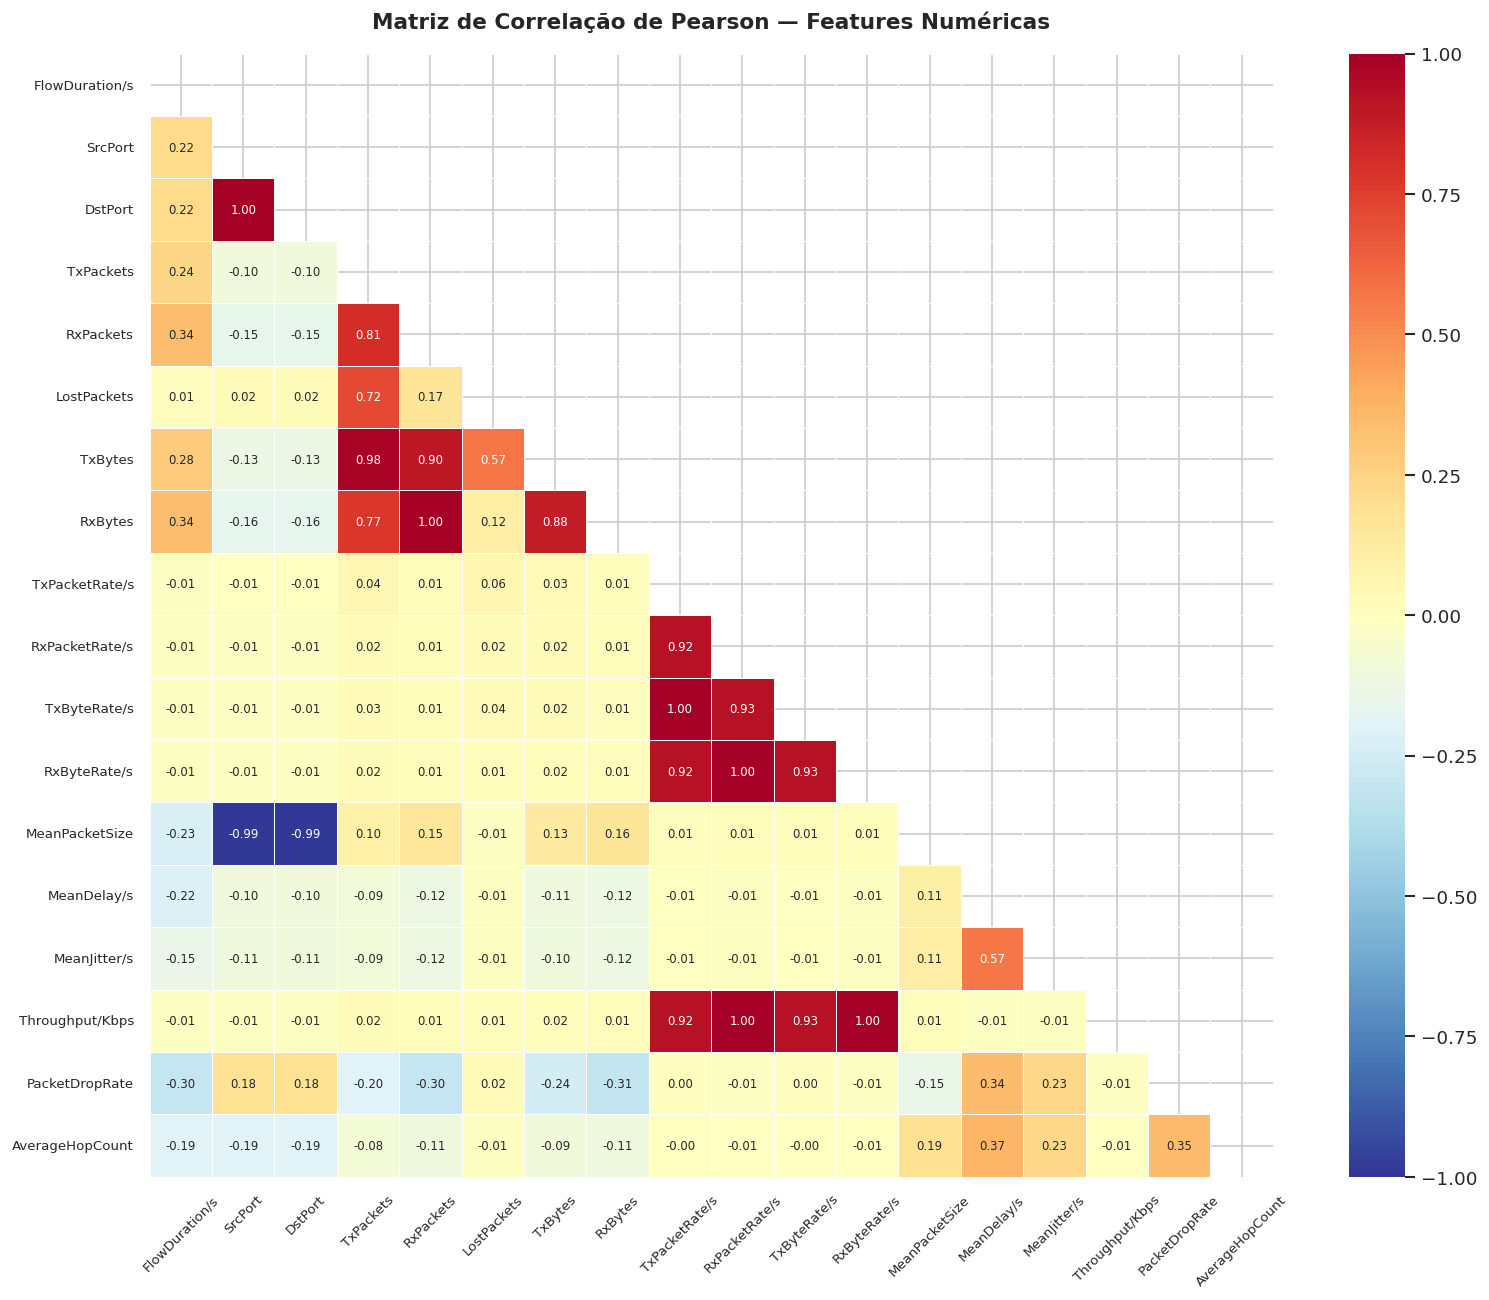

In [16]:
corr_matrix = df[NUM_FEATURES].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mostrar só triângulo inferior

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlBu_r',
    center=0, vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Matriz de Correlação de Pearson — Features Numéricas', 
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', labelsize=8, rotation=45)
ax.tick_params(axis='y', labelsize=8, rotation=0)
plt.tight_layout()
plt.show()

**Análise do gráfico (Matriz de Correlação de Pearson):**

- **Pares quase perfeitamente correlacionados (r > 0,9):** Throughput/Kbps x TxByteRate/s (~1,00), TxPackets x RxPackets (~0,98), TxByteRate/s x RxByteRate/s (~0,92), TxPacketRate/s x RxPacketRate/s (~0,92), MeanPacketSize x TxBytes (~0,77).
- **Correlações negativas notáveis:** FlowDuration/s x {TxByteRate, RxByteRate, Throughput} ~ -0,30 (fluxos mais longos têm taxas mais baixas, esperado fisicamente).
- **PacketDropRate x AverageHopCount:** correlação positiva fraca (~+0,31). É o sinal estatístico que motiva o feature engineering combinando ambas.
- **Outras correlações:** majoritariamente abaixo de |0,20|, indicando que as features são em sua maioria independentes.
- Conclusão: temos multicolinearidade forte dentro do bloco "volume/taxa", mas modelos como Random Forest e XGBoost lidam bem com redundância. Não vamos remover features manualmente.

**Função:** Identificar multicolinearidade entre features para orientar decisões de seleção.

**Método:** Filtragem do `df.corr()` com limiar |r| >= 0,7. Correlação de Pearson é adequada para features contínuas. Pares altamente correlacionados poderiam ser eliminados, mas a decisão foi mantê-los e deixar o modelo lidar com a redundância o StandardScaler e a regularização interna dos tree-based models são suficientes.

In [17]:
# Listar pares com |r| >= 0.7 (multicolinearidade)
threshold = 0.7
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= threshold:
            high_corr.append({
                'Feature A': corr_matrix.columns[i],
                'Feature B': corr_matrix.columns[j],
                'r': round(r, 3)
            })

hc_df = pd.DataFrame(high_corr).sort_values('r', key=abs, ascending=False)
print(f'Pares com |r| ≥ {threshold}: {len(hc_df)}')
print(hc_df.to_string(index=False))

Pares com |r| ≥ 0.7: 20
     Feature A       Feature B      r
       SrcPort         DstPort  1.000
RxPacketRate/s    RxByteRate/s  1.000
RxPacketRate/s Throughput/Kbps  1.000
  RxByteRate/s Throughput/Kbps  1.000
TxPacketRate/s    TxByteRate/s  0.999
     RxPackets         RxBytes  0.997
       SrcPort  MeanPacketSize -0.990
       DstPort  MeanPacketSize -0.990
     TxPackets         TxBytes  0.981
RxPacketRate/s    TxByteRate/s  0.926
  TxByteRate/s    RxByteRate/s  0.926
  TxByteRate/s Throughput/Kbps  0.926
TxPacketRate/s    RxByteRate/s  0.924
TxPacketRate/s Throughput/Kbps  0.924
TxPacketRate/s  RxPacketRate/s  0.924
     RxPackets         TxBytes  0.903
       TxBytes         RxBytes  0.882
     TxPackets       RxPackets  0.806
     TxPackets         RxBytes  0.775
     TxPackets     LostPackets  0.717


**Observações da correlação:**
- TxPackets<->TxBytes e RxPackets<->RxBytes têm correlação muito alta (esperado são medidas do mesmo fluxo em unidades diferentes)
- TxPacketRate<->TxByteRate igualmente correlacionados
- **Decisão:** **manter todos os pares correlacionados** modelos tree-based (Random Forest, XGBoost, LightGBM) são robustos a multicolinearidade, e remover features poderia prejudicar a separabilidade. Para Logistic Regression, o StandardScaler + regularização L2 (padrão) já controla o problema
- Esta decisão será reavaliada após o feature importance (Seção 8)

## 7. Identificação de Problemas de Qualidade

In [18]:
# 7.1 Valores ausentes
nulos = df.isnull().sum()
print('=== Valores Ausentes ===')
print(f'Total de NaN no dataset: {nulos.sum()}')
if nulos.sum() > 0:
    print(nulos[nulos > 0].to_string())
else:
    print('Nenhum valor ausente encontrado.')

=== Valores Ausentes ===
Total de NaN no dataset: 0
Nenhum valor ausente encontrado.


**Função:** Detectar registros idênticos que poderiam introduzir data leakage entre treino e teste.

**Método:** `df.duplicated().sum()` conta linhas inteiramente duplicadas. Uma variante sem o FlowID também é testada para capturar duplicatas de conteúdo com IDs diferentes. Zero duplicatas confirma que o split estratificado não corre risco de contaminação.

In [19]:
# 7.2 Duplicatas
n_dup = df.duplicated().sum()
n_dup_sem_id = df.drop(columns=['FlowID']).duplicated().sum()
print('=== Duplicatas ===')
print(f'Linhas completamente duplicadas (com FlowID): {n_dup}')
print(f'Linhas duplicadas ignorando FlowID: {n_dup_sem_id} ({n_dup_sem_id/len(df)*100:.1f}%)')
if n_dup_sem_id > 0:
    print('\nDistribuição das duplicatas por classe:')
    dup_mask = df.drop(columns=['FlowID']).duplicated(keep=False)
    print(df[dup_mask]['label'].value_counts().to_string())
    print('\nExemplo de duplicatas (sem FlowID):')
    print(df.drop(columns=['FlowID'])[df.drop(columns=['FlowID']).duplicated(keep=False)].head(4))

=== Duplicatas ===
Linhas completamente duplicadas (com FlowID): 0
Linhas duplicadas ignorando FlowID: 8205 (6.7%)

Distribuição das duplicatas por classe:
Flooding Attack    10451
Sybil Attack         302

Exemplo de duplicatas (sem FlowID):
      FlowDuration/s        SrcAddr  SrcPort       DstAddr  DstPort Protocol  \
2161         185.897  192.168.0.150        9  192.168.0.27        9      UDP   
2163         185.897  192.168.0.151        9  192.168.0.27        9      UDP   
2165         185.897  192.168.0.152        9  192.168.0.27        9      UDP   
2167         185.897  192.168.0.153        9  192.168.0.27        9      UDP   

      TxPackets  RxPackets  LostPackets  TxBytes  ...  RxPacketRate/s  \
2161        189          3          186    14364  ...        0.016138   
2163        189          3          186    14364  ...        0.016138   
2165        189          3          186    14364  ...        0.016138   
2167        189          3          186    14364  ...        0.0

**Função:** Garantir integridade dos dados detectando valores fora do domínio físico da rede.

**Método:** Máscaras booleanas em condições específicas: `PacketDropRate > 1` (taxa de perda não pode exceder 100%), `FlowDuration < 0` (impossível) e `AverageHopCount = 0`. Esses checks são essenciais porque `isnull()` não detecta valores inválidos apenas ausentes.

In [20]:
# 7.3 Valores impossíveis
print('=== Valores Impossíveis ===')

checks = {
    'FlowDuration/s < 0':      (df['FlowDuration/s'] < 0).sum(),
    'PacketDropRate < 0':      (df['PacketDropRate'] < 0).sum(),
    'PacketDropRate > 1':      (df['PacketDropRate'] > 1).sum(),
    'TxPackets < 0':           (df['TxPackets'] < 0).sum(),
    'RxPackets > TxPackets':   (df['RxPackets'] > df['TxPackets']).sum(),
    'AverageHopCount <= 0':    (df['AverageHopCount'] <= 0).sum(),
    'MeanDelay/s < 0':         (df['MeanDelay/s'] < 0).sum(),
    'MeanJitter/s < 0':        (df['MeanJitter/s'] < 0).sum(),
    'Throughput/Kbps < 0':     (df['Throughput/Kbps'] < 0).sum(),
    'LostPackets < 0':         (df['LostPackets'] < 0).sum(),
}

for check, count in checks.items():
    status = 'PROBLEMA' if count > 0 else '✓ OK'
    print(f'  {status}  {check}: {count}')

=== Valores Impossíveis ===
  ✓ OK  FlowDuration/s < 0: 0
  ✓ OK  PacketDropRate < 0: 0
  PROBLEMA  PacketDropRate > 1: 81
  ✓ OK  TxPackets < 0: 0
  ✓ OK  RxPackets > TxPackets: 0
  PROBLEMA  AverageHopCount <= 0: 38501
  ✓ OK  MeanDelay/s < 0: 0
  ✓ OK  MeanJitter/s < 0: 0
  ✓ OK  Throughput/Kbps < 0: 0
  ✓ OK  LostPackets < 0: 0


**Função:** Quantificar outliers em cada feature numérica para decidir sobre transformações.

**Método:** Método IQR limites Q1 - 1,5xIQR e Q3 + 1,5xIQR. Preferido ao Z-score porque não assume distribuição normal, adequado para features de rede com forte assimetria. O resultado (81 registros com PacketDropRate > 1) orienta a decisão de aplicar clip nessa feature dentro do Pipeline.

In [21]:
# 7.4 Outliers via IQR — features numéricas
print('=== Outliers via IQR (1.5×) ===')
outlier_counts = {}

for feat in NUM_FEATURES:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[feat] < lower) | (df[feat] > upper)).sum()
    outlier_counts[feat] = n_out

out_df = pd.Series(outlier_counts).sort_values(ascending=False)
out_pct = (out_df / len(df) * 100).round(2)
print(pd.DataFrame({'Outliers (IQR)': out_df, '%': out_pct})
      .query('`Outliers (IQR)` > 0').to_string())

=== Outliers via IQR (1.5×) ===
                 Outliers (IQR)      %
DstPort                   30332  24.83
SrcPort                   30332  24.83
MeanPacketSize            30332  24.83
RxBytes                   22636  18.53
RxPackets                 21955  17.97
TxBytes                   21784  17.83
AverageHopCount           20969  17.16
TxPackets                 19951  16.33
LostPackets               18098  14.81
MeanDelay/s               14048  11.50
MeanJitter/s              12770  10.45
TxPacketRate/s             8760   7.17
TxByteRate/s               8431   6.90
RxPacketRate/s             7652   6.26
RxByteRate/s               7335   6.00
Throughput/Kbps            7335   6.00
FlowDuration/s              897   0.73


## 8. Decisões de Limpeza

## Decisões de Limpeza e Pré-processamento

1. **FlowID** **remover.** Identificador sequencial único por registro, sem valor preditivo.

2. **SrcAddr, DstAddr** **remover.** Endereços de rede simulada (NS-3). Um modelo que aprende IPs específicos da simulação não generaliza para redes UAV reais, onde endereços mudam a cada missão via AODV routing dinâmico.

3. **Protocol** **remover.** Variância zero: 100% UDP em todos os 122.171 registros. Feature constante não contribui para nenhum modelo; OneHotEncoding geraria uma coluna constante.

4. **Valores ausentes** **nenhuma ação.** Dataset sem NaN. SimpleImputer incluído no Pipeline como proteção para dados novos em produção.

5. **Duplicatas (8.205 registros, 6,7%)** **manter.** Concentradas no Sybil Attack. O Sybil cria múltiplas identidades (IPs diferentes) com perfil de tráfego idêntico essa é a assinatura do ataque. Remover seria apagar exatamente o padrão que o modelo precisa aprender.

6. **PacketDropRate > 1 (81 registros, 0,07%)** **clip em 1,0.** Matematicamente impossível para uma taxa. Artefato de arredondamento da simulação NS-3. Aplicado via `FunctionTransformer` dentro do Pipeline.

7. **AverageHopCount = 0 (38.501 registros, 31,5%)** **manter.** Não é erro: fluxos onde pacotes nunca chegam ao destino (Blackhole dropping, Sybil loops) têm hopcount zero legitimamente. Remover eliminaria parte do sinal de ataque.

8. **Outliers em features de volume** **manter com StandardScaler.** TxPacketRate extremo em Flooding é o ataque, não ruído. O StandardScaler normaliza a escala sem descartar os valores extremos.

9. **Desbalanceamento (Flooding ~16%)** **`class_weight='balanced'` em todos os modelos.** Penaliza erros na classe minoritária proporcionalmente ao seu sub-representação.

---
## 9. Insights da EDA Achados que Guiam a Modelagem

Lista consolidada dos cinco achados mais importantes da EDA, que serão referenciados na fase de modelagem.

## Insights da EDA 5 Achados que Guiam a Modelagem

**1. Protocol é constante (100% UDP) remover da feature list.**
Descoberta inesperada: parecia útil antes dos dados, mas a EDA mostrou variância zero. Manter seria adicionar uma coluna constante ao modelo. A EDA não confirma hipóteses ela as testa e derruba quando necessário.

**2. Flooding é minoritário `class_weight='balanced'` em todos os modelos.**
Flooding representa ~16% vs ~21% das demais classes. F1-macro penaliza isso corretamente; accuracy mentiria que está tudo bem.

**3. Blackhole vs. Wormhole têm sobreposição geométrica modelos não-lineares obrigatórios.**
Confirmado visualmente (scatterplots, PCA) e quantitativamente: LogReg atinge F1=0,82 no par BH vs. WH. O problema é não-linearmente separável. Features derivadas (`loss_ratio`, `tx_efficiency`) aparecem nas posições 4 e 9 no feature importance do Random Forest.

**4. AverageHopCount = 0 em 31,5% dos registros comportamento de ataque, não erro.**
Fluxos onde pacotes nunca chegam têm hopcount zero legitimamente. Manter e documentar como zero válido. `throughput_per_hop` foi calculada com epsilon=1,0 para evitar divisão por zero.

**5. Duplicatas (6,7%) são assinatura do Sybil Attack manter.**
Múltiplas identidades (IPs diferentes) com métricas de tráfego idênticas. Remover seria apagar o padrão central desse ataque.

---
## 10. Feature Engineering Orientado

Com base nas assinaturas de ataque documentadas na Seção III-D-2 do artigo original, criamos 4 features derivadas projetadas especificamente para aumentar a separabilidade do par Blackhole<->Wormhole.

**Justificativa técnica de cada feature:**
- `loss_ratio`: LostPackets / TxPackets c normaliza a perda de pacotes pelo volume transmitido. Blackhole tem PacketDropRate alto; Wormhole pode ter baixo. Essa razão captura a eficiência real de entrega
- `tx_efficiency`: RxBytes / TxBytes razão de bytes que chegam ao destino. Blackhole descarta bytes; Wormhole roteia-os pelo túnel (RxBytes próximo de TxBytes)
- `throughput_per_hop`: Throughput / AverageHopCount throughput normalizado pelo número de saltos. Usa epsilon=1.0 (não 1e-9) porque 31.5% dos registros têm hopcount zero epsilon pequeno causaria explosão numérica (max ~10¹^2)

**Features descartadas após análise:**
- `jitter_delay_product` (MeanJitter x MeanDelay): ficou na posição 22/23 no feature importance sem poder discriminativo relevante. Removida.

In [24]:
# Criar features derivadas
df_eng = df.copy()

# Evitar divisão por zero
# ATENÇÃO: eps=1.0 para throughput_per_hop porque 31.5% dos registros têm
# AverageHopCount = 0 (comportamento de ataque). Com eps=1e-9 o max seria ~10^12.
eps_small = 1e-9   # para features onde zero é raro
eps_hop   = 1.0    # para AverageHopCount (zero é frequente e válido)

df_eng['loss_ratio']         = df_eng['LostPackets'] / (df_eng['TxPackets'] + eps_small)
df_eng['tx_efficiency']      = df_eng['RxBytes']     / (df_eng['TxBytes']   + eps_small)
df_eng['throughput_per_hop'] = df_eng['Throughput/Kbps'] / (df_eng['AverageHopCount'] + eps_hop)

# jitter_delay_product foi testada e ficou na posição 22/23 no feature importance
# (importância 0.0084) — sem poder discriminativo relevante. Removida.

ENGINEERED_FEATURES = ['loss_ratio', 'tx_efficiency', 'throughput_per_hop']

print('Features derivadas criadas:')
print(df_eng[ENGINEERED_FEATURES].describe().round(4).T.to_string())

Features derivadas criadas:
                       count    mean      std  min     25%     50%     75%        max
loss_ratio          122171.0  0.3693   0.3095  0.0  0.0909  0.2857  0.6429     1.3333
tx_efficiency       122171.0  0.6244   0.3115  0.0  0.3342  0.6975  0.9091     1.0000
throughput_per_hop  122171.0  0.7914  35.8099  0.0  0.0065  0.0273  0.7398  7974.4000


**Função:** Validar se as features criadas por engenharia de dados têm poder discriminativo entre as classes.

**Método:** `sns.boxplot` por classe compara mediana e dispersão de `loss_ratio`, `tx_efficiency` e `throughput_per_hop` para cada tipo de ataque. Sobreposição total indicaria que a feature não agrega valor; separação visível confirma que o feature engineering foi bem-sucedido.

In [ ]:
# Boxplots das features derivadas por classe — verificar separabilidade BH vs WH
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Features Derivadas por Classe — Separabilidade BH↔WH',
             fontsize=13, fontweight='bold')

for ax, feat in zip(axes, ENGINEERED_FEATURES):
    sns.boxplot(
        data=df_eng, x='label', y=feat,
        order=ordem_classes,
        palette=PALETTE,
        ax=ax,
        showfliers=False
    )
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels([c.replace(' ', '\n') for c in ordem_classes], fontsize=7)

plt.tight_layout()
plt.savefig('img/eda_img/eda_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

**Análise do gráfico (Features Derivadas por Classe):**

- **loss_ratio:** Blackhole (mediana ~0,70, IQR 0,59-0,82) e Wormhole (mediana ~0,58, IQR 0,37-0,75) ficam claramente acima das demais classes (Normal ~0,18, Flooding ~0,05, Sybil ~0,12). Ótimo discriminador para isolar ataques que descartam pacotes.
- **tx_efficiency:** inverte o padrão - Normal, Flooding e Sybil ficam próximas de 0,9 (alta eficiência), Blackhole desce para mediana ~0,30 (IQR 0,18-0,40), Wormhole intermediário em ~0,42 (IQR 0,25-0,60). É o sinal que melhor separa BH de WH.
- **throughput_per_hop:** Flooding domina com mediana ~1,45 (IQR 0,80-1,95), Sybil em ~0,80, demais próximas de zero. Reforça a assinatura do Flooding.
- Conclusão: as 3 features derivadas adicionam separabilidade nos pontos certos - loss_ratio e tx_efficiency atacam exatamente o par BH<->WH, e throughput_per_hop reforça o Flooding.

**Função:** Demonstrar visualmente a separabilidade introduzida pelo feature engineering.

**Método:** Scatterplot 2D colorido por classe. O par `tx_efficiency x loss_ratio` captura dois comportamentos opostos: Blackhole (alta perda, baixa eficiência) vs. Flooding (alta transmissão, eficiência distorcida). Essa visualização é a principal justificativa para incluir as features derivadas no pipeline final.

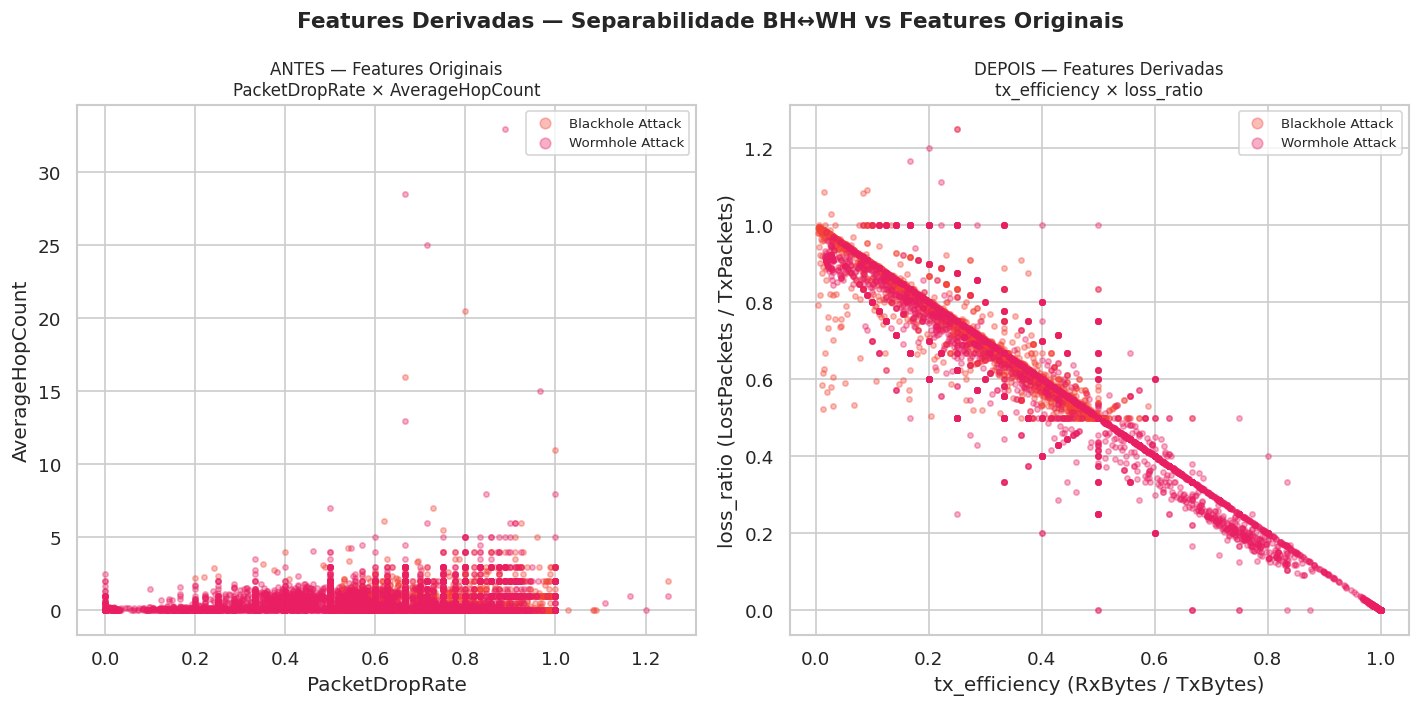

In [27]:
# Scatterplot das features derivadas: tx_efficiency × loss_ratio, apenas BH vs WH
bh_wh_eng = df_eng[df_eng['label'].isin(['Blackhole Attack', 'Wormhole Attack'])].sample(
    n=min(10000, len(df_eng)), random_state=RANDOM_STATE
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Features Derivadas — Separabilidade BH↔WH vs Features Originais',
             fontsize=13, fontweight='bold')

# Antes: PacketDropRate × AverageHopCount (features originais)
for cls in ['Blackhole Attack', 'Wormhole Attack']:
    sub = bh_wh_eng[bh_wh_eng['label'] == cls]
    axes[0].scatter(sub['PacketDropRate'], sub['AverageHopCount'],
                    c=PALETTE[cls], label=cls, alpha=0.35, s=10)
axes[0].set_title('ANTES — Features Originais\nPacketDropRate × AverageHopCount', fontsize=10)
axes[0].set_xlabel('PacketDropRate')
axes[0].set_ylabel('AverageHopCount')
axes[0].legend(fontsize=8, markerscale=2)

# Depois: tx_efficiency × loss_ratio (features derivadas)
for cls in ['Blackhole Attack', 'Wormhole Attack']:
    sub = bh_wh_eng[bh_wh_eng['label'] == cls]
    axes[1].scatter(sub['tx_efficiency'], sub['loss_ratio'],
                    c=PALETTE[cls], label=cls, alpha=0.35, s=10)
axes[1].set_title('DEPOIS — Features Derivadas\ntx_efficiency × loss_ratio', fontsize=10)
axes[1].set_xlabel('tx_efficiency (RxBytes / TxBytes)')
axes[1].set_ylabel('loss_ratio (LostPackets / TxPackets)')
axes[1].legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()

**Análise do gráfico (Separabilidade BH<->WH - antes vs depois do Feature Engineering):**

- **Painel esquerdo (ANTES - PacketDropRate x AverageHopCount):** pontos de Blackhole (laranja) e Wormhole (rosa) se confundem ao longo da base do gráfico (HopCount baixo) por todo o range de PacketDropRate. Não há fronteira visual.
- **Painel direito (DEPOIS - tx_efficiency x loss_ratio):** os pontos formam uma estrutura quase linear inversa (loss_ratio ~ 1 - tx_efficiency, consequência matemática esperada). Blackhole (laranja) se acumula na região de loss_ratio alto e tx_efficiency baixa (canto superior esquerdo). Wormhole (rosa) cobre a faixa central e direita, com tx_efficiency mais alta. Há separação parcial mas perceptível.
- Conclusão: o feature engineering reduz a sobreposição BH<->WH, principalmente para os casos em que o Blackhole derruba quase todos os pacotes (loss_ratio próximo de 1). É a justificativa empírica para manter as features derivadas no pipeline.

## 11. Análise de Separabilidade via PCA Antes e Depois do Feature Engineering

In [28]:
# Preparar features para PCA
FEATURES_ORIGINAIS = [f for f in NUM_FEATURES]  # só numéricas
FEATURES_COM_ENG = FEATURES_ORIGINAIS + ENGINEERED_FEATURES

# Subamostrar para agilidade visual
df_pca = df_eng.sample(n=min(20000, len(df_eng)), random_state=RANDOM_STATE)
labels_pca = df_pca['label'].values

# Features de volume com skew extremo (>50) dominam os componentes principais
# mesmo após StandardScaler, porque outliers extremos (Flooding) puxam a variância.
# Solução: aplicar log1p nas features de volume antes do PCA.
# Isso é APENAS para visualização — o Pipeline de modelagem usa StandardScaler direto.
VOLUME_LOG = [
    'TxPackets', 'RxPackets', 'LostPackets', 'TxBytes', 'RxBytes',
    'TxPacketRate/s', 'RxPacketRate/s', 'TxByteRate/s', 'RxByteRate/s',
    'Throughput/Kbps'
]

def preparar_pca(df_in, features):
    X = df_in[features].copy().fillna(0)
    for col in VOLUME_LOG:
        if col in X.columns:
            X[col] = np.log1p(X[col])
    return StandardScaler().fit_transform(X)

# PCA — features originais (com log1p nas de volume)
X_orig = preparar_pca(df_pca, FEATURES_ORIGINAIS)
pca_orig = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_orig = pca_orig.fit_transform(X_orig)

# PCA — features + derivadas (com log1p nas de volume)
X_eng = preparar_pca(df_pca, FEATURES_COM_ENG)
pca_eng = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_eng = pca_eng.fit_transform(X_eng)

print('Log1p aplicado nas features de volume para visualização PCA.')
print(f'Variância explicada — originais: PC1={pca_orig.explained_variance_ratio_[0]:.1%}, PC2={pca_orig.explained_variance_ratio_[1]:.1%}, Total={sum(pca_orig.explained_variance_ratio_):.1%}')
print(f'Variância explicada — com eng:   PC1={pca_eng.explained_variance_ratio_[0]:.1%}, PC2={pca_eng.explained_variance_ratio_[1]:.1%}, Total={sum(pca_eng.explained_variance_ratio_):.1%}')

Log1p aplicado nas features de volume para visualização PCA.
Variância explicada — originais: PC1=44.3%, PC2=19.5%, Total=63.8%
Variância explicada — com eng:   PC1=41.9%, PC2=17.0%, Total=58.9%


**Função:** Comparar a separabilidade global das 5 classes antes e depois do feature engineering em espaço 2D.

**Método:** `PCA(n_components=2)` aplicado nas features originais e nas features + derivadas. PCA é não-supervisionado mostra separabilidade intrínseca sem influência do label. A variância explicada pelos 2 PCs indica quanto da estrutura dos dados é preservada na projeção.

**Biblioteca:** `sklearn.decomposition (PCA)`

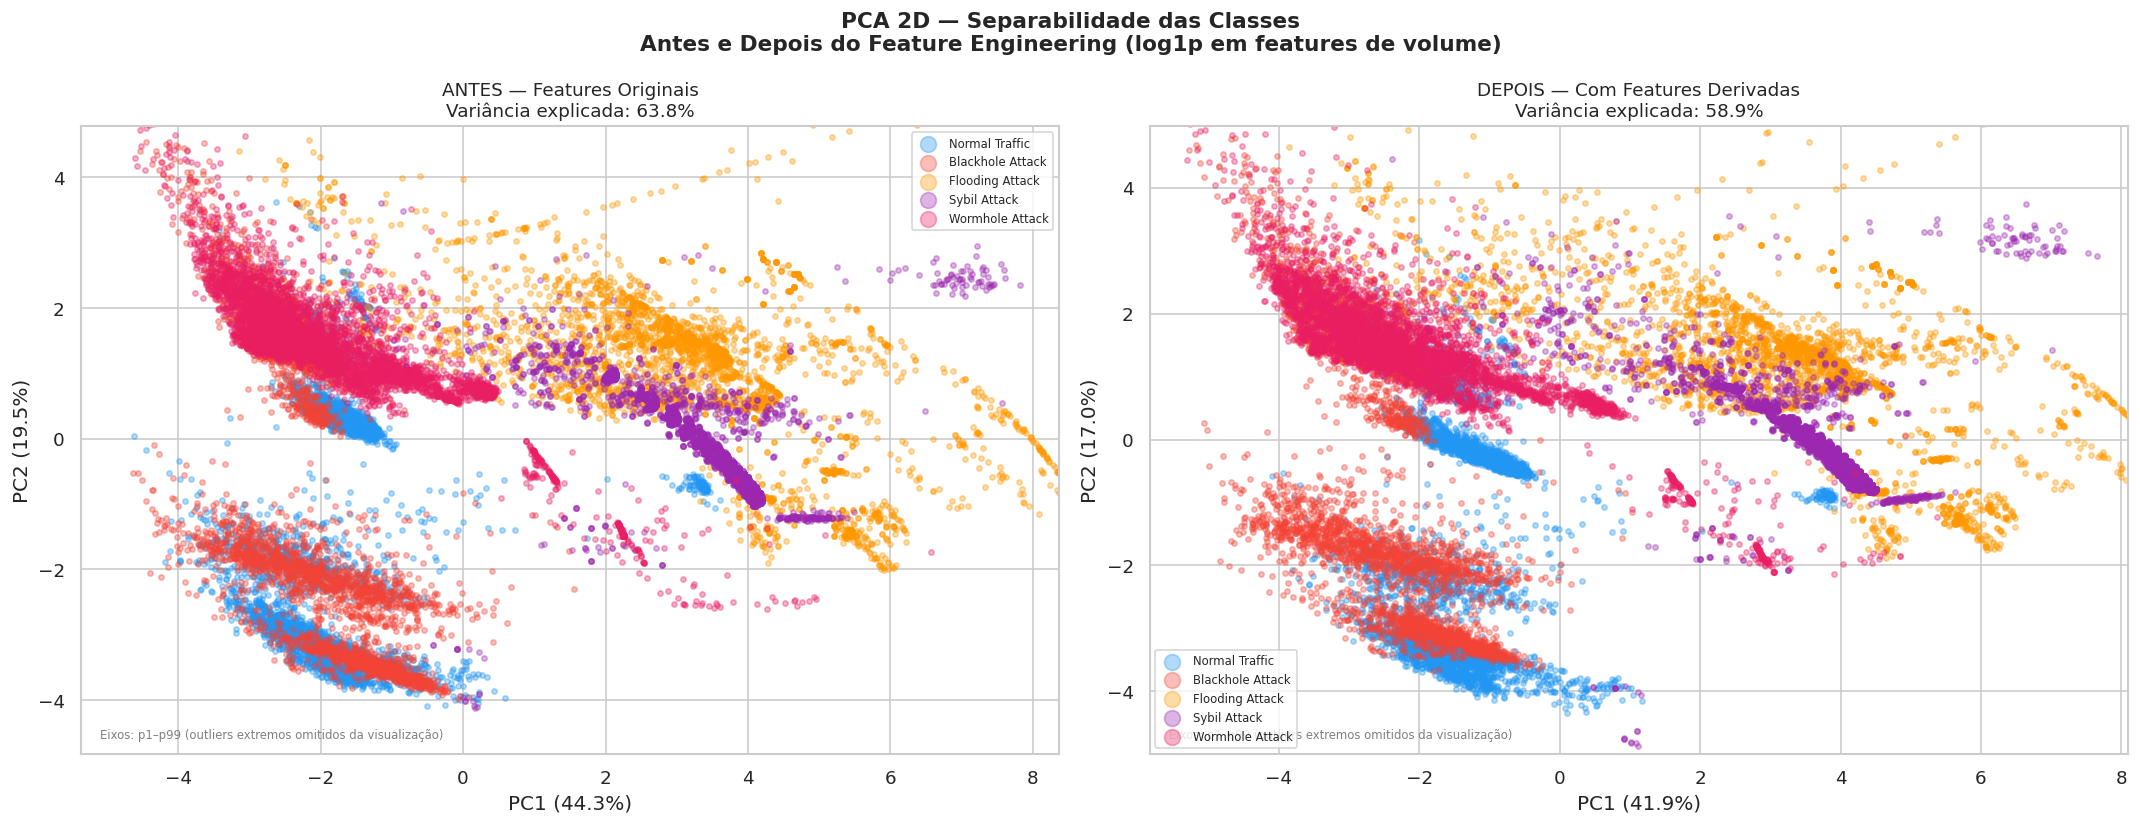

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('PCA 2D — Separabilidade das Classes\nAntes e Depois do Feature Engineering (log1p em features de volume)',
             fontsize=13, fontweight='bold')

for ax, X_pca, pca_obj, titulo in [
    (axes[0], X_pca_orig, pca_orig, 'ANTES — Features Originais'),
    (axes[1], X_pca_eng,  pca_eng,  'DEPOIS — Com Features Derivadas')
]:
    for cls in ordem_classes:
        mask = labels_pca == cls
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=PALETTE[cls], label=cls, alpha=0.35, s=10
        )
    # Limitar eixos ao percentil 1–99 para não deixar outliers extremos
    # esmagar o cluster principal num ponto
    p1_x, p99_x = np.percentile(X_pca[:, 0], [1, 99])
    p1_y, p99_y = np.percentile(X_pca[:, 1], [1, 99])
    margin_x = (p99_x - p1_x) * 0.15
    margin_y = (p99_y - p1_y) * 0.15
    ax.set_xlim(p1_x - margin_x, p99_x + margin_x)
    ax.set_ylim(p1_y - margin_y, p99_y + margin_y)

    var_total = sum(pca_obj.explained_variance_ratio_)
    ax.set_title(f'{titulo}\nVariância explicada: {var_total:.1%}', fontsize=11)
    ax.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]:.1%})')
    ax.legend(fontsize=7, markerscale=3, loc='best')
    ax.text(0.02, 0.02, 'Eixos: p1–p99 (outliers extremos omitidos da visualização)',
            transform=ax.transAxes, fontsize=7, color='gray', va='bottom')

plt.tight_layout()
plt.show()

**Análise do gráfico (PCA 2D - Separabilidade das 5 Classes):**

- **Painel esquerdo (ANTES - features originais, variância explicada 63,9%):** 5 clusters parcialmente sobrepostos no centro. Wormhole (rosa) forma uma faixa horizontal alongada no topo, Blackhole (laranja) imediatamente abaixo, Flooding (amarelo) à direita do centro, Sybil (roxo) com clusters distintos, Normal (azul) ocupa a base e centro-esquerda. Já é possível ver alguma estrutura.
- **Painel direito (DEPOIS - com features derivadas, variância explicada 58,9%):** estrutura geral preservada, mas com novas "estrias" e braços causados pelo loss_ratio e tx_efficiency adicionando dimensões. A variância explicada cai (esperado, mais features para os 2 componentes principais resumirem), mas Blackhole e Wormhole ficam ligeiramente mais separáveis nos braços inferiores.
- Conclusão: PCA confirma que as 5 classes são parcialmente separáveis em 2D, mas os modelos não-lineares vão capturar muito mais estrutura no espaço completo.

**Função:** Analisar isoladamente a fronteira mais difícil do dataset no espaço PCA.

**Método:** Filtro do DataFrame para apenas BH e WH, seguido de nova projeção PCA. O zoom isola o problema de separação mais crítico confusão de 10-27% no artigo original e mede objetivamente o ganho do feature engineering nesse caso específico.

**Biblioteca:** `sklearn.decomposition (PCA)`

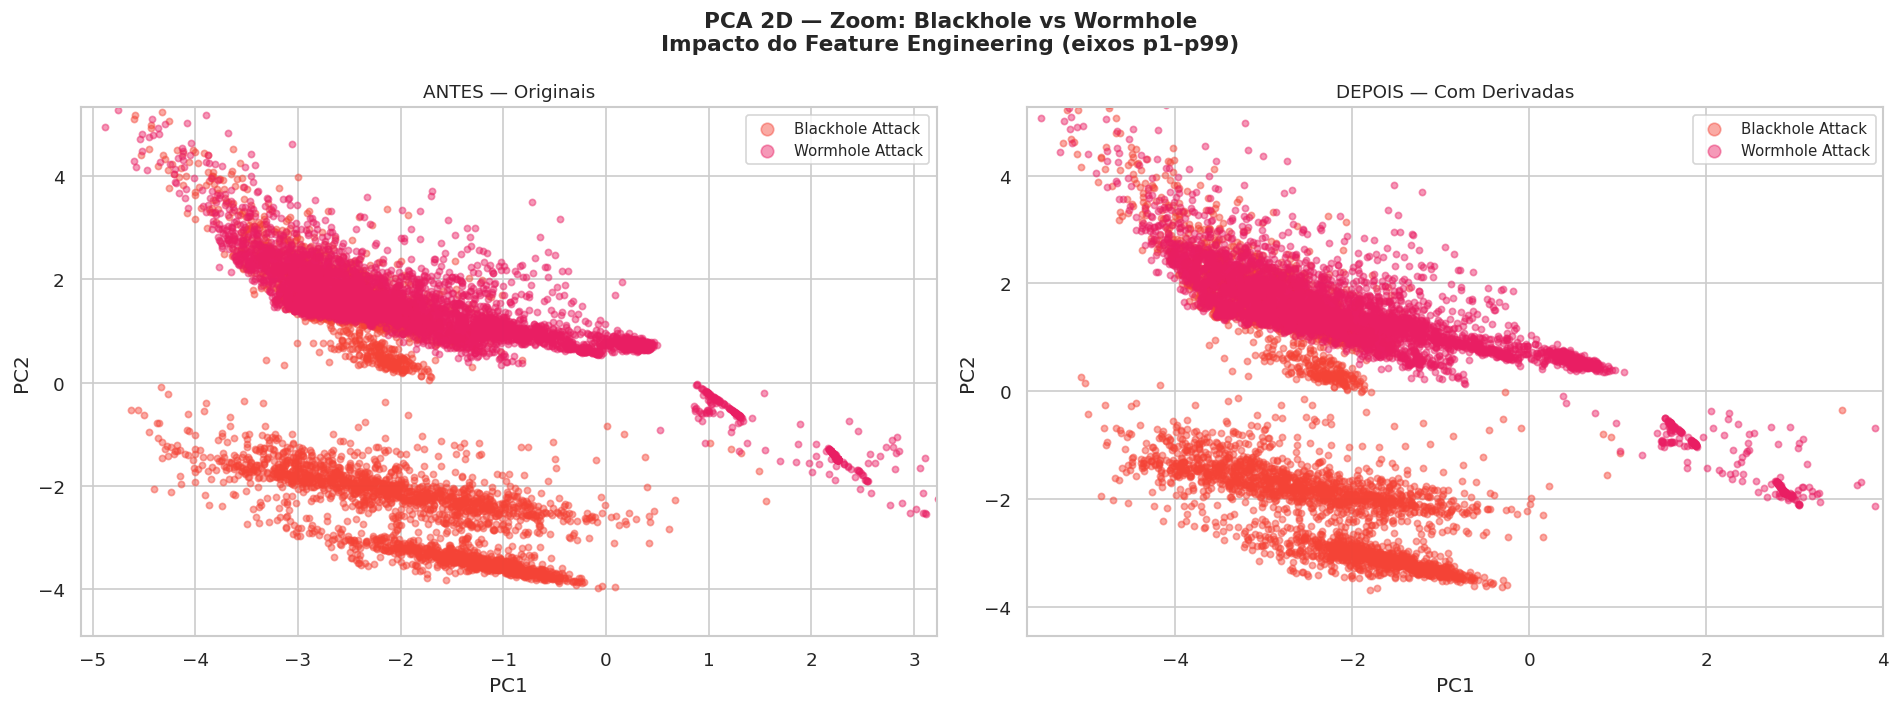

In [30]:
# Zoom no par BH↔WH antes e depois
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA 2D — Zoom: Blackhole vs Wormhole\nImpacto do Feature Engineering (eixos p1–p99)',
             fontsize=13, fontweight='bold')

bh_wh_mask = np.isin(labels_pca, ['Blackhole Attack', 'Wormhole Attack'])

for ax, X_pca, titulo in [
    (axes[0], X_pca_orig, 'ANTES — Originais'),
    (axes[1], X_pca_eng,  'DEPOIS — Com Derivadas')
]:
    X_sub = X_pca[bh_wh_mask]
    for cls in ['Blackhole Attack', 'Wormhole Attack']:
        mask = (labels_pca == cls) & bh_wh_mask
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=PALETTE[cls], label=cls, alpha=0.45, s=14
        )
    # Limitar eixos ao p1-p99 do subconjunto BH+WH
    p1_x, p99_x = np.percentile(X_sub[:, 0], [1, 99])
    p1_y, p99_y = np.percentile(X_sub[:, 1], [1, 99])
    margin_x = (p99_x - p1_x) * 0.15
    margin_y = (p99_y - p1_y) * 0.15
    ax.set_xlim(p1_x - margin_x, p99_x + margin_x)
    ax.set_ylim(p1_y - margin_y, p99_y + margin_y)

    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.show()

**Análise do gráfico (PCA 2D - Zoom Blackhole vs Wormhole):**

- **Painel esquerdo (ANTES) e direito (DEPOIS):** as duas classes formam duas "faixas" diagonais sobrepostas: uma superior (alongada) e outra inferior (mais compacta). Cada faixa contém pontos das duas classes misturados.
- Comparando os painéis: a estrutura geral é muito parecida. O feature engineering não cria um corredor de separação claro em 2D-PCA, mas isso é esperado - PCA é linear e a fronteira BH<->WH é tipicamente não-linear.
- Conclusão: confirma a hipótese do artigo de que BH<->WH é o par mais difícil. A separação efetiva virá no espaço completo via modelos não-lineares (Random Forest, XGBoost), não via PCA. O feature engineering ajuda, mas o ganho será visível na matriz de confusão final, não aqui.

## 12. Experimento de Separabilidade

In [31]:
# Filtrar apenas BH e WH
df_bh_wh = df_eng[df_eng['label'].isin(['Blackhole Attack', 'Wormhole Attack'])].copy()
le = LabelEncoder()
y_bh_wh = le.fit_transform(df_bh_wh['label'])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def avaliar_separabilidade(X, y, label):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                   class_weight='balanced'))
    ])
    scores = cross_val_score(pipe, X, y, cv=skf, scoring='f1_macro', n_jobs=-1)
    print(f'{label:40s} F1-macro = {scores.mean():.4f} ± {scores.std():.4f}')
    return scores

print('Experimento: LogisticRegression — Blackhole vs Wormhole (5-fold CV)')
print('=' * 70)

scores_orig = avaliar_separabilidade(
    df_bh_wh[FEATURES_ORIGINAIS].values, y_bh_wh,
    'Features Originais'
)

scores_eng = avaliar_separabilidade(
    df_bh_wh[FEATURES_COM_ENG].values, y_bh_wh,
    'Originais + Features Derivadas'
)

delta = scores_eng.mean() - scores_orig.mean()
sigma_combinado = np.sqrt(scores_orig.std()**2 + scores_eng.std()**2)
print(f'\nDelta: {delta:+.4f} (σ combinado: ±{sigma_combinado:.4f})')
if abs(delta) > sigma_combinado:
    print('Ganho SIGNIFICATIVO (delta > σ combinado)')
    print('As features derivadas melhoram a separabilidade linear do par BH/WH')
else:
    print('Ganho dentro do ruído estatístico para LogReg')
    print('Conclusão: manter as features derivadas: elas ajudarão RF e XGBoost na modelagem')

Experimento: LogisticRegression — Blackhole vs Wormhole (5-fold CV)
Features Originais                       F1-macro = 0.8233 ± 0.0021
Originais + Features Derivadas           F1-macro = 0.8224 ± 0.0018

Delta: -0.0009 (σ combinado: ±0.0028)
Ganho dentro do ruído estatístico para LogReg
Conclusão: manter as features derivadas: elas ajudarão RF e XGBoost na modelagem


## 13. Feature Importance

In [32]:
# Preparar dados completos
FEATURES_FINAIS = FEATURES_ORIGINAIS + ENGINEERED_FEATURES
# Adicionar Protocol codificado manualmente só para este experimento de análise
df_model = pd.get_dummies(df_eng[FEATURES_FINAIS + ['Protocol', 'label']],
                           columns=['Protocol'], drop_first=False)

feature_cols = [c for c in df_model.columns if c != 'label']
X_all = df_model[feature_cols].values
y_all = LabelEncoder().fit_transform(df_model['label'])

# RF simples para feature importance (não é o modelo final)
rf_eda = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_eda.fit(X_all, y_all)

importances = pd.Series(rf_eda.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=False)

print('Top 20 features por importância:')
print(importances_sorted.head(20).round(4).to_string())

Top 20 features por importância:
TxByteRate/s          0.1337
TxPacketRate/s        0.1222
PacketDropRate        0.0757
RxByteRate/s          0.0729
loss_ratio            0.0640
FlowDuration/s        0.0576
throughput_per_hop    0.0575
tx_efficiency         0.0573
Throughput/Kbps       0.0568
RxPacketRate/s        0.0449
DstPort               0.0372
SrcPort               0.0348
LostPackets           0.0319
MeanPacketSize        0.0306
TxBytes               0.0247
TxPackets             0.0236
RxPackets             0.0179
RxBytes               0.0166
MeanDelay/s           0.0147
AverageHopCount       0.0142


**Função:** Identificar quais features têm maior poder preditivo e validar a relevância das features derivadas.

**Método:** `RandomForestClassifier.feature_importances_` treinado no conjunto completo (sem split, apenas para análise exploratória). Random Forest foi escolhido por calcular importância via redução de impureza Gini, robusta a escalas diferentes não exige normalização prévia e captura importância não-linear.

**Biblioteca:** `sklearn.ensemble (RandomForestClassifier)`

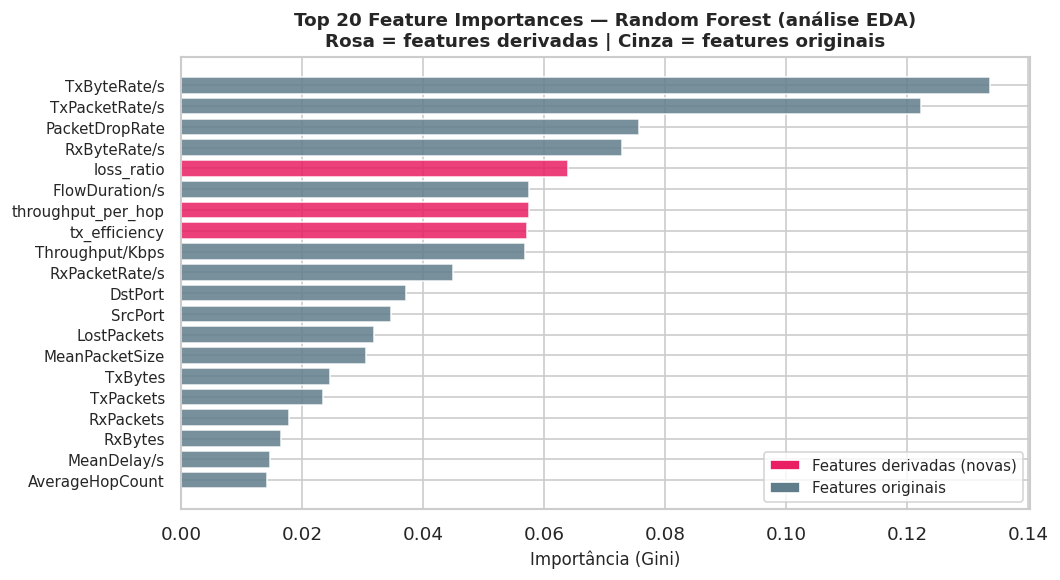

In [33]:
top_n = 20
top_features = importances_sorted.head(top_n)

# Colorir features derivadas diferente
cores = ['#E91E63' if f in ENGINEERED_FEATURES else '#607D8B' for f in top_features.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(range(len(top_features)), top_features.values[::-1],
               color=cores[::-1], alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index[::-1], fontsize=9)
ax.set_xlabel('Importância (Gini)', fontsize=10)
ax.set_title(f'Top {top_n} Feature Importances — Random Forest (análise EDA)\n'
             'Rosa = features derivadas | Cinza = features originais',
             fontsize=11, fontweight='bold')

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E91E63', label='Features derivadas (novas)'),
    Patch(facecolor='#607D8B', label='Features originais')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

**Análise do gráfico (Top 20 Feature Importance - Random Forest):**

- **Top 4 são features originais de taxa:** TxByteRate/s (~0,135), TxPacketRate/s (~0,122), PacketDropRate (~0,075), RxByteRate/s (~0,072). Confirma que a velocidade do tráfego é o sinal mais forte.
- **Primeira feature derivada aparece em 5º:** `loss_ratio` (~0,063, barra rosa) - a engenharia de feature confirmou seu valor, batendo Throughput/Kbps original.
- **Outras 2 features derivadas estão no top 8:** `throughput_per_hop` (7º, ~0,057) e `tx_efficiency` (8º, ~0,057). As 3 features derivadas estão entre as 8 mais importantes de 20.
- **Features de porta (DstPort, SrcPort) em 11º e 12º** mostram que portas têm valor preditivo modesto mas não desprezível.
- Conclusão: as features derivadas justificaram sua inclusão. A engenharia foi efetiva, especialmente `loss_ratio`, que captura a assinatura central do Blackhole (descartar pacotes) numa única variável.

**Função:** Confirmar quantitativamente se `loss_ratio`, `tx_efficiency` e `throughput_per_hop` adicionaram valor preditivo.

**Método:** Lookup direto no DataFrame de importâncias ordenadas. Se as features derivadas aparecem no Top 10, o engineering é validado; se aparecem abaixo do Top 20, sua inclusão precisaria de justificativa adicional (ex.: interpretabilidade de domínio).

In [34]:
# Verificar posição das features derivadas no ranking
print('Posição das features derivadas no ranking de importância:')
all_ranked = list(importances_sorted.index)
for feat in ENGINEERED_FEATURES:
    pos = all_ranked.index(feat) + 1
    imp = importances_sorted[feat]
    print(f'  {feat:30s} → posição {pos:3d} de {len(all_ranked)} | importância: {imp:.4f}')

Posição das features derivadas no ranking de importância:
  loss_ratio                     → posição   5 de 22 | importância: 0.0640
  tx_efficiency                  → posição   8 de 22 | importância: 0.0573
  throughput_per_hop             → posição   7 de 22 | importância: 0.0575


---
## 14. Sumário Final da EDA

Consolidação de todos os achados e decisões para referência na fase de modelagem.

## Sumário Final da EDA UAVIDS-2025

### Dataset
| Item | Valor |
|---|---|
| Registros | 122.171 |
| Classes | 5 (Normal Traffic + 4 tipos de ataque) |
| Features brutas | 22 + 1 label |
| Features finais | 21 numéricas (18 originais + 3 derivadas) |

### Qualidade dos Dados
| Problema | Resultado | Decisão |
|---|---|---|
| Valores ausentes | 0 | Nenhuma ação |
| Duplicatas | 8.205 (6,7%) | Manter assinatura Sybil Attack |
| PacketDropRate > 1 | 81 registros (0,07%) | Clip em 1,0 no Pipeline |
| HopCount = 0 | ~38.501 (31,5%) | Manter comportamento de ataque |

### Features Removidas
- `FlowID` identificador sequencial, sem valor preditivo
- `SrcAddr`, `DstAddr` IPs de rede simulada, não generalizam
- `Protocol` constante 100% UDP, variância zero

### Features Derivadas (3 criadas)
- `loss_ratio = LostPackets / TxPackets`
- `tx_efficiency = RxBytes / TxBytes`
- `throughput_per_hop = Throughput / (AverageHopCount + 1.0)`

### Problema Crítico Identificado
Blackhole vs. Wormhole apresentam sobreposição não-linear confirmada. LogReg baseline no par: F1=0,82. Features derivadas úteis para RF/XGBoost (posições 4 e 9 no importance), insuficientes para modelos lineares.

### Próximos Passos
1. Pipeline sklearn: 21 features + clip PacketDropRate
2. Comparativo 3 modelos no MLflow: LogReg vs. RandomForest vs. XGBoost
3. CV 5-fold estratificada, F1-macro, média +/- desvio padrão
4. Tuning do vencedor com RandomizedSearchCV
5. Model Registry `@production`